## Per questi plot sono stati usati i dataset decoys e native (per quest'ultimo sono stati presi solo i complessi presenti anche in decoys)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


# Radial distribution functions
## Osservazioni qualitative
RDF distanza fisica sono particamente sovrapponibili tra native e decoys

RDF Zernike e roughness sono più basse per i decoys (tranne Zernike per >40Å). RDF Zernike decoy ha andamento meno lineare dei native.

Dopo 30Å e ancora di più dopo 40Å le RDF diventano rumorose

La complementarità di forma viene ottimizzata al centro del binding site, non come l'idrofobicità che era ottimizzata intorno a 9Å

## Interpretazione
Gli algoritmi di docking quando generano un decoy riescono comunque a ricostruire la giusta distanza tra le proteine, ma rendono il binding site un po' più piatto e sorprendentemente ottimizzano meglio la complementarità di forma (anche se c'è da tenere conto che più le superfici sono piatte e più è facile avere complementarità di forma, quindi in parte potrebbe essere legato al fatto che la roughness decoy è minore della roughness native)

## Idea
Si potrebbe vedere qual è il valore medio della distanza di Zernike per random patches (lo chiamo Z). Sarebbe interessante per due motivi:

-Potremmo vedere se e quando le RDF raggiungono Z, cioè quando il binding site comincia a diventare simile a random patches e quindi la complementarità di forma non viene più ottimizzata. Magari succede quando le RDF saturano?

-Potremmo definire la metrica complementarità di forma (da sostituire alla distanza di Zernike) come Z - distanza_zernike. In questo modo si avrebbe un andamento inverso a quello attuale, quindi con valori alti quando la distanza di zernike è bassa, e lo zero corrisponderebbe al caso random patches

  physical / native: norm counts 10, real counts 25
  physical / decoy: norm counts 10, real counts 25


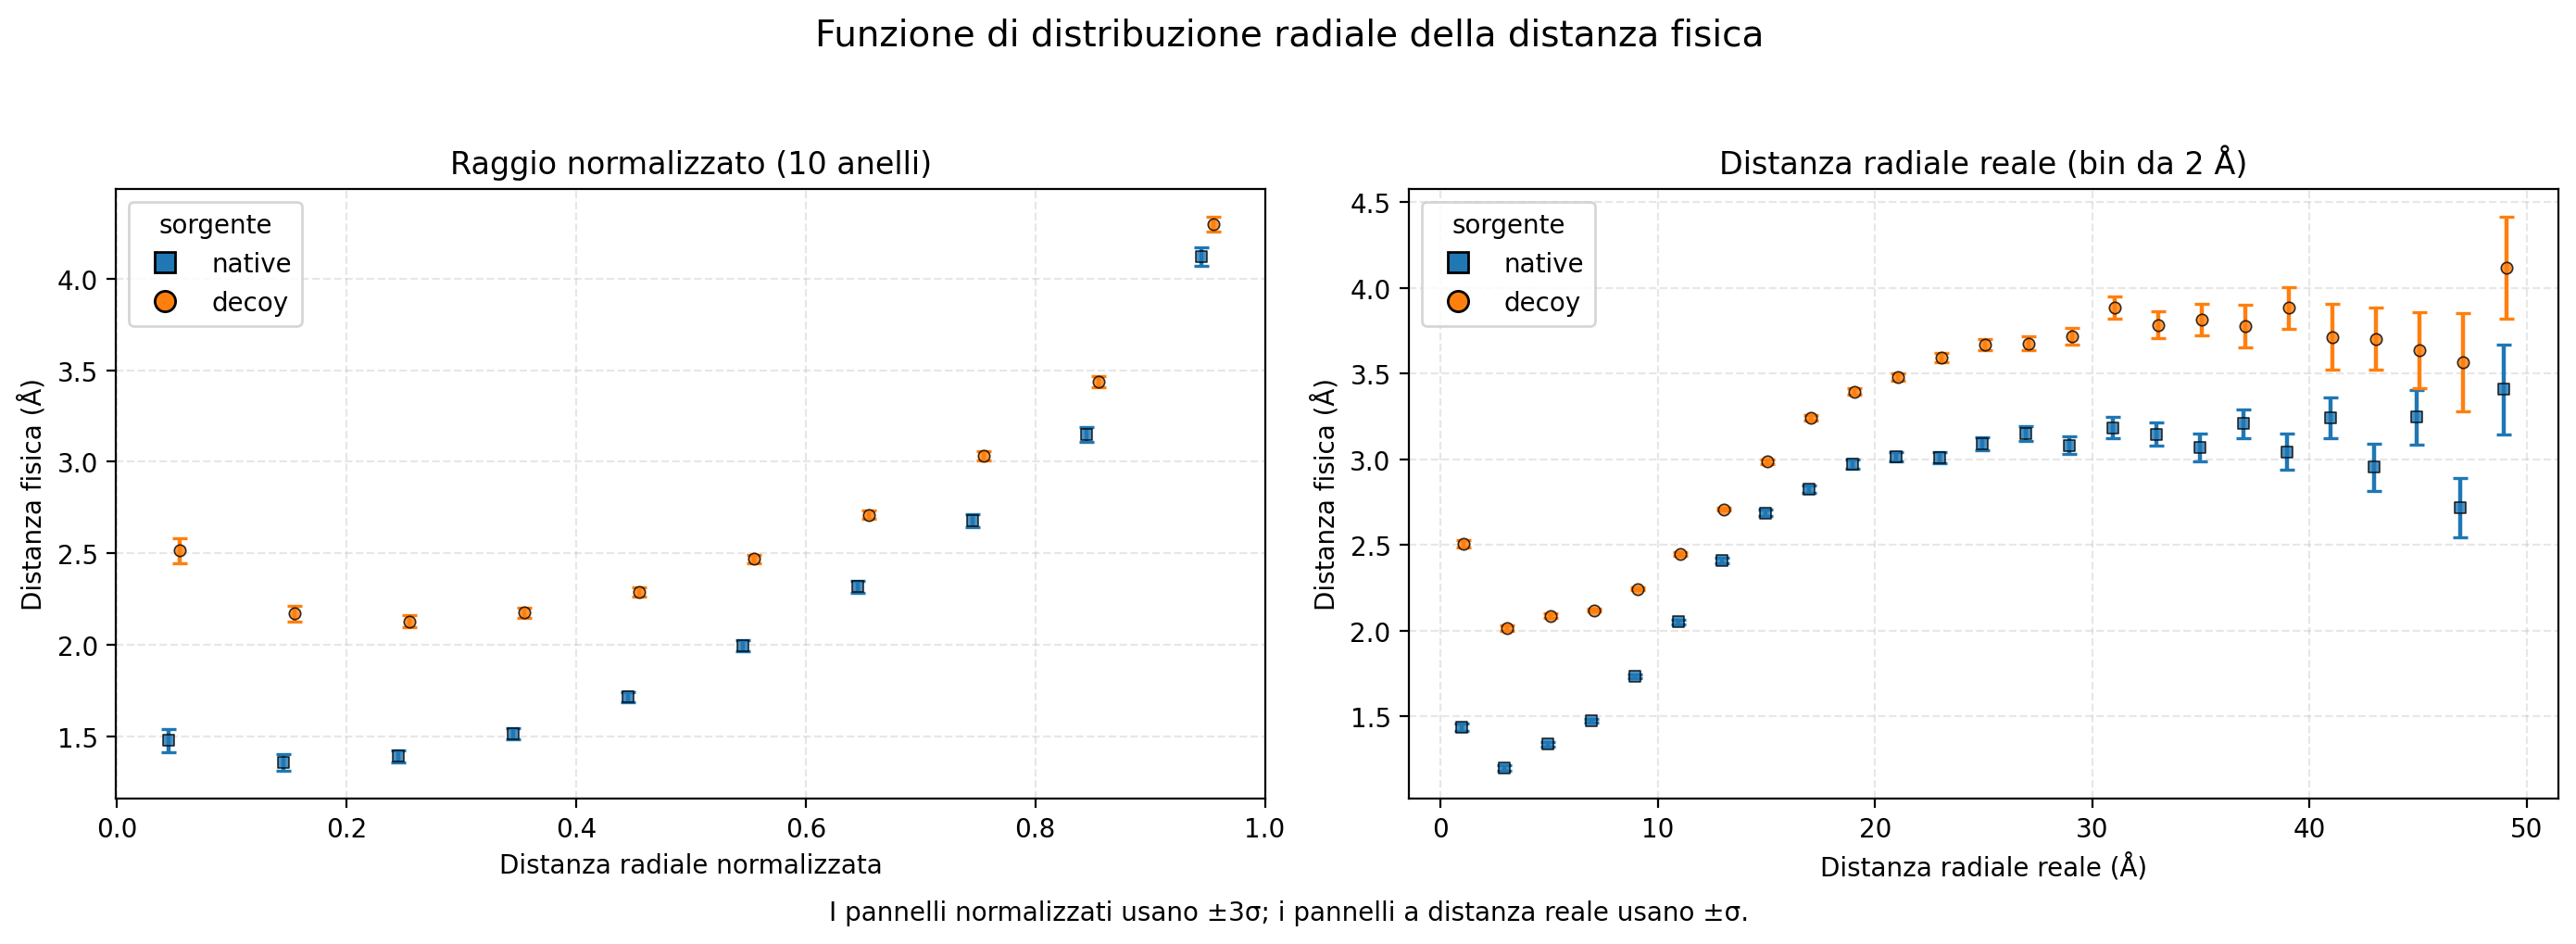

  zernike / native: norm counts 10, real counts 25
  zernike / decoy: norm counts 10, real counts 25


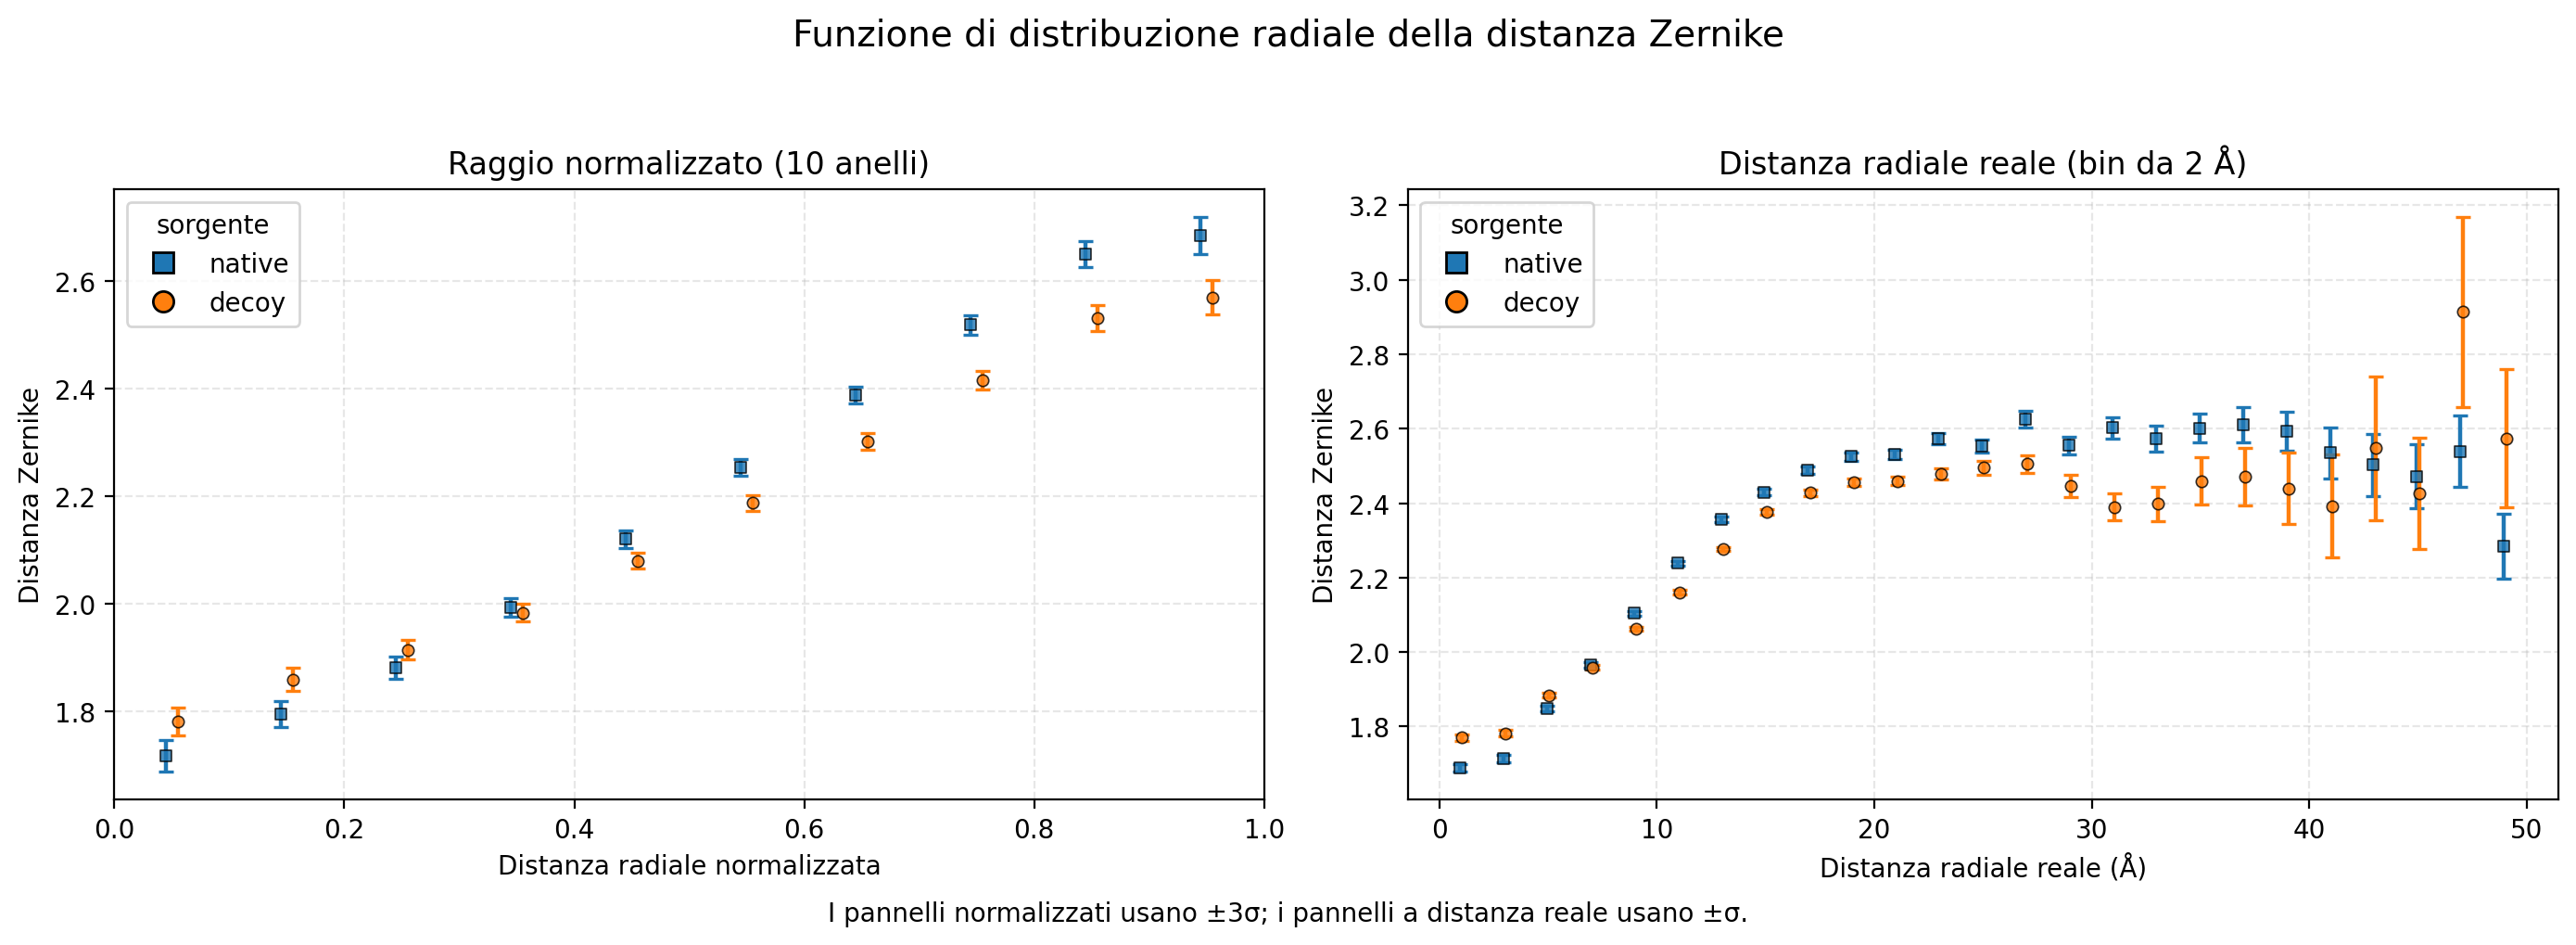

  roughness / native: norm counts 10, real counts 25
  roughness / decoy: norm counts 10, real counts 25


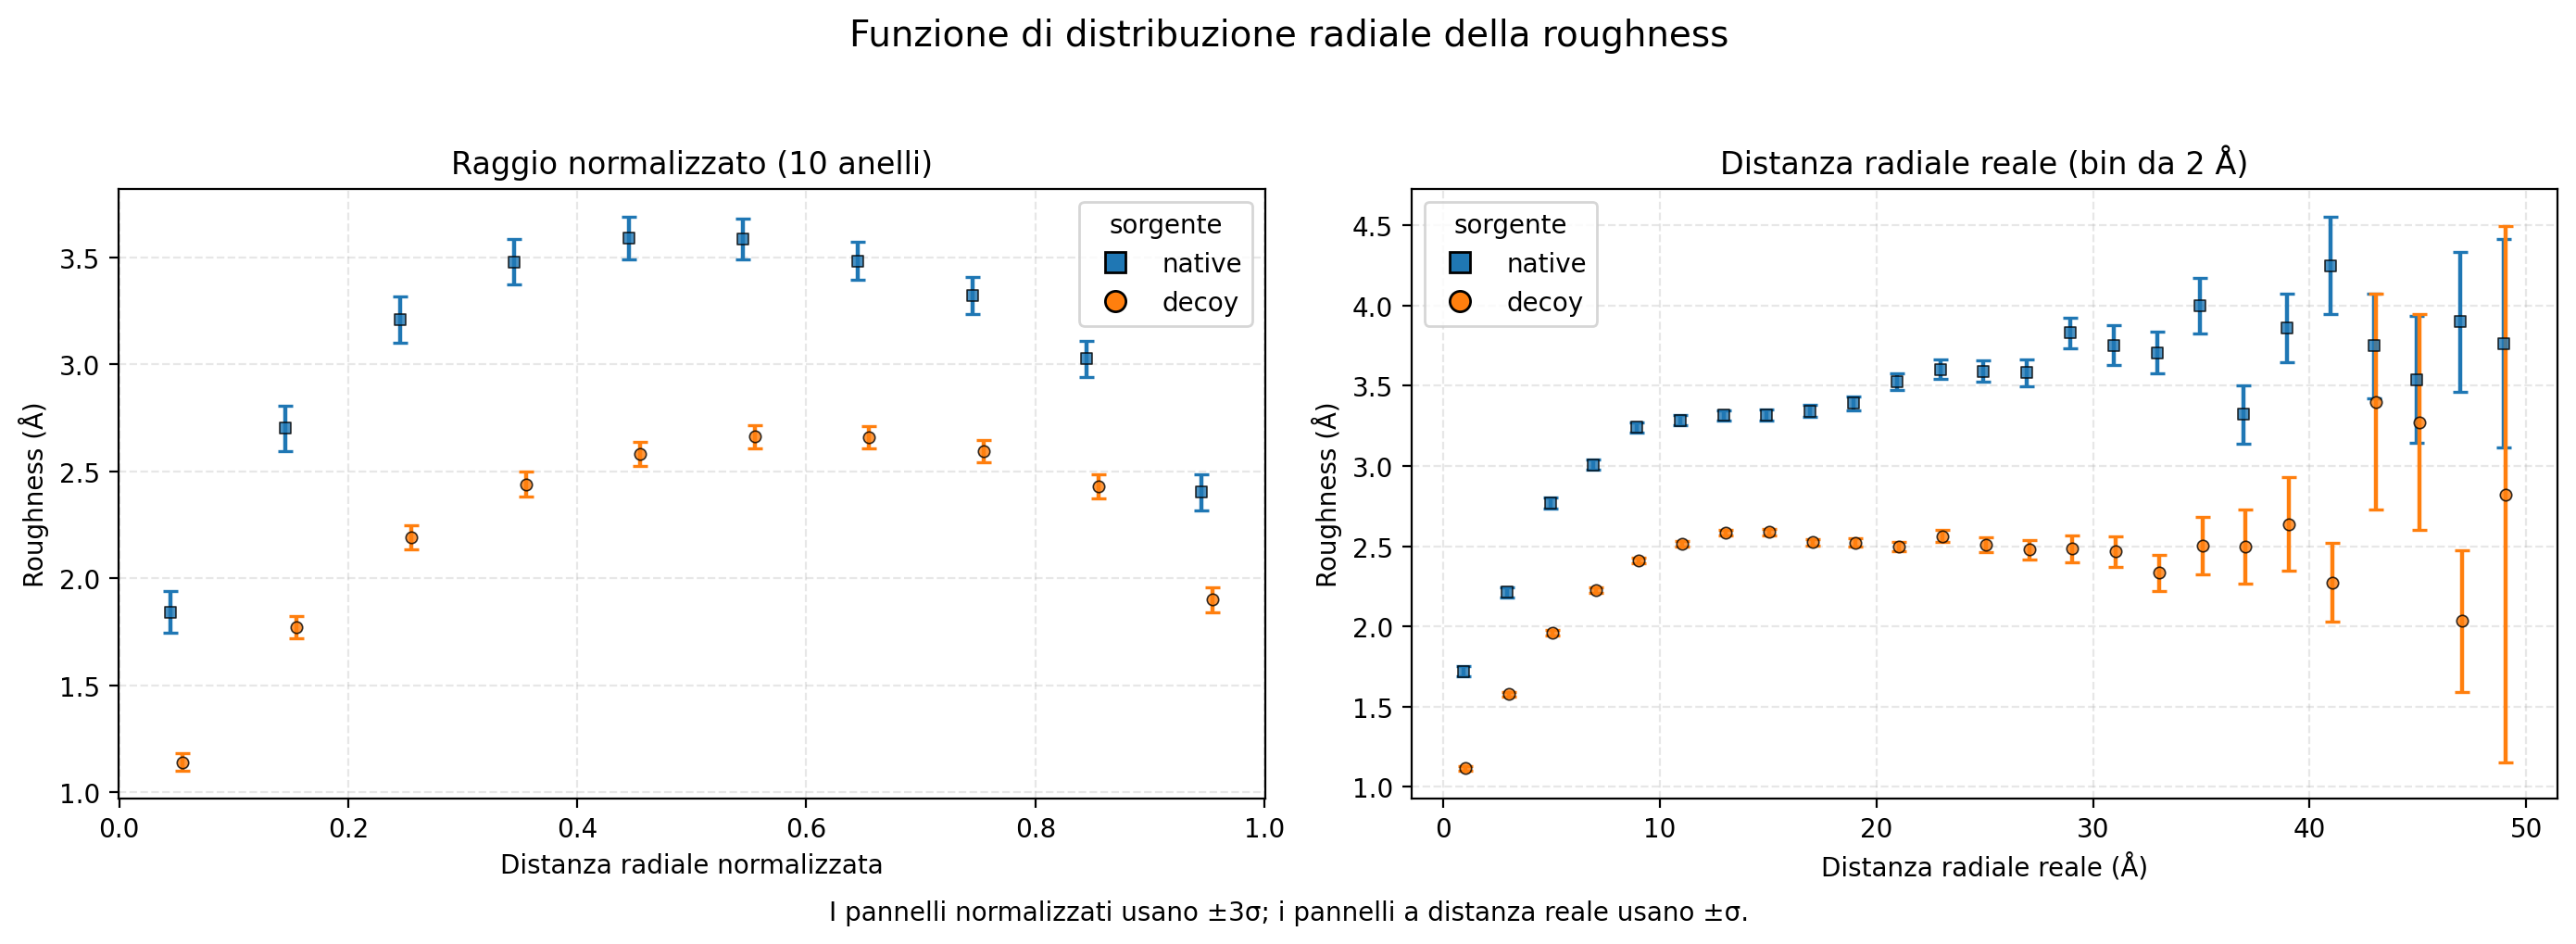

In [2]:
import re
from matplotlib.lines import Line2D

# Confronto native vs decoy con lo stesso stile di dataset_plot.py
source_specs = [
    ('native', native_df.copy(), '#1f77b4', 's'),
    ('decoy', decoys_df.copy(), '#ff7f0e', 'o'),
]

ring_pattern = re.compile(r'^physical_ring(\d+)_mean$')
ring_ids = sorted({int(m.group(1)) for df in [native_df, decoys_df] for c in df.columns for m in [ring_pattern.match(c)] if m})
if len(ring_ids) == 0:
    raise ValueError('Nessun ring trovato nelle colonne physical_ring*_mean')

n_rings = len(ring_ids)
x_norm = np.array([(rid - 0.5) / n_rings for rid in ring_ids], dtype=float)

bin_width = 2.0
max_x = 50.0
bin_edges = np.arange(0.0, max_x + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width / 2.0


def mean_and_sample_uncertainty(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    mean_value = float(np.mean(values))
    if len(values) == 1:
        return mean_value, 0.0
    return mean_value, float(np.std(values, ddof=1) / np.sqrt(len(values)))


def propagated_mean_uncertainty(uncertainties):
    uncertainties = np.asarray(uncertainties, dtype=float)
    uncertainties = uncertainties[np.isfinite(uncertainties)]
    if len(uncertainties) == 0:
        return np.nan
    if len(uncertainties) == 1:
        return float(uncertainties[0])
    return float(np.sqrt(np.sum(uncertainties ** 2)) / len(uncertainties))


def combined_uncertainty(sample_uncertainty, propagated_uncertainty):
    if not np.isfinite(sample_uncertainty) and not np.isfinite(propagated_uncertainty):
        return np.nan
    if not np.isfinite(sample_uncertainty):
        return float(propagated_uncertainty)
    if not np.isfinite(propagated_uncertainty):
        return float(sample_uncertainty)
    return float(np.sqrt(sample_uncertainty ** 2 + propagated_uncertainty ** 2))


def compute_metric_stats(df, metric):
    is_roughness = metric == 'roughness'
    norm_mean = []
    norm_err = []

    for rid in ring_ids:
        value_col = f'{metric}_ring{rid}' if is_roughness else f'{metric}_ring{rid}_mean'
        unc_col = None if is_roughness else f'{metric}_ring{rid}_uncertainty'

        if value_col not in df.columns:
            norm_mean.append(np.nan)
            norm_err.append(np.nan)
            continue

        values = pd.to_numeric(df[value_col], errors='coerce').to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if len(values) == 0:
            norm_mean.append(np.nan)
            norm_err.append(np.nan)
            continue

        mean_value, sample_uncertainty = mean_and_sample_uncertainty(values)
        propagated_uncertainty = np.nan
        if unc_col is not None and unc_col in df.columns:
            uncertainties = pd.to_numeric(df[unc_col], errors='coerce').to_numpy(dtype=float)
            uncertainties = uncertainties[np.isfinite(uncertainties)]
            propagated_uncertainty = propagated_mean_uncertainty(uncertainties)

        norm_mean.append(mean_value)
        norm_err.append(combined_uncertainty(sample_uncertainty, propagated_uncertainty))

    per_bin_vals = {i: [] for i in range(len(bin_centers))}
    per_bin_uncs = {i: [] for i in range(len(bin_centers))}

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get('radius', np.nan), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for rid in ring_ids:
            value_col = f'{metric}_ring{rid}' if is_roughness else f'{metric}_ring{rid}_mean'
            unc_col = None if is_roughness else f'{metric}_ring{rid}_uncertainty'

            value = pd.to_numeric(row.get(value_col, np.nan), errors='coerce')
            if not np.isfinite(value):
                continue

            x_real = (rid - 0.5) * radius / n_rings
            if not np.isfinite(x_real) or x_real < 0 or x_real > max_x:
                continue

            bin_idx = int(np.floor(x_real / bin_width))
            bin_idx = min(bin_idx, len(bin_centers) - 1)
            per_bin_vals[bin_idx].append(float(value))

            if unc_col is not None:
                unc_val = pd.to_numeric(row.get(unc_col, np.nan), errors='coerce')
                if np.isfinite(unc_val):
                    per_bin_uncs[bin_idx].append(float(unc_val))

    real_mean = []
    real_err = []
    for i in range(len(bin_centers)):
        values = np.array(per_bin_vals[i], dtype=float)
        values = values[np.isfinite(values)]
        if len(values) == 0:
            real_mean.append(np.nan)
            real_err.append(np.nan)
            continue

        mean_value, sample_uncertainty = mean_and_sample_uncertainty(values)
        uncertainties = np.array(per_bin_uncs[i], dtype=float)
        uncertainties = uncertainties[np.isfinite(uncertainties)]
        propagated_uncertainty = propagated_mean_uncertainty(uncertainties) if len(uncertainties) > 0 else np.nan

        real_mean.append(mean_value)
        real_err.append(combined_uncertainty(sample_uncertainty, propagated_uncertainty))

    return {
        'norm_mean': np.array(norm_mean, dtype=float),
        'norm_err': np.array(norm_err, dtype=float),
        'real_mean': np.array(real_mean, dtype=float),
        'real_err': np.array(real_err, dtype=float),
    }


def plot_metric_rdf(metric, metric_title, norm_ylabel, real_ylabel):
    source_stats = []
    for source_label, df, color, marker in source_specs:
        stats = compute_metric_stats(df, metric)
        source_stats.append((source_label, color, marker, stats))
        print(f"  {metric} / {source_label}: norm counts {np.isfinite(stats['norm_mean']).sum()}, real counts {np.isfinite(stats['real_mean']).sum()}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for source_label, color, marker, stats in source_stats:
        norm_x_offset = -0.005 if source_label == 'native' else 0.005
        real_x_offset = -0.05 if source_label == 'native' else 0.05

        axes[0].errorbar(
            x_norm + norm_x_offset,
            stats['norm_mean'],
            yerr=3.0 * stats['norm_err'],
            fmt='none',
            ecolor=color,
            elinewidth=1.6,
            capsize=3,
            capthick=1.2,
            zorder=2,
        )
        axes[0].scatter(
            x_norm + norm_x_offset,
            stats['norm_mean'],
            s=20,
            marker=marker,
            color=color,
            edgecolors='black',
            linewidth=0.6,
            alpha=0.8,
            zorder=3,
        )

        axes[1].errorbar(
            bin_centers + real_x_offset,
            stats['real_mean'],
            yerr=stats['real_err'],
            fmt='none',
            ecolor=color,
            elinewidth=1.6,
            capsize=3,
            capthick=1.2,
            zorder=2,
        )
        axes[1].scatter(
            bin_centers + real_x_offset,
            stats['real_mean'],
            s=20,
            marker=marker,
            color=color,
            edgecolors='black',
            linewidth=0.6,
            alpha=0.8,
            zorder=3,
        )

    axes[0].set_title('Raggio normalizzato (10 anelli)')
    axes[0].set_xlabel('Distanza radiale normalizzata')
    axes[0].set_ylabel(norm_ylabel)
    axes[0].grid(True, alpha=0.3, linestyle='--')

    axes[1].set_title('Distanza radiale reale (bin da 2 Å)')
    axes[1].set_xlabel('Distanza radiale reale (Å)')
    axes[1].set_ylabel(real_ylabel)
    axes[1].grid(True, alpha=0.3, linestyle='--')

    source_handles = []
    for source_label, _, marker, color in [(s[0], s[1], s[2], s[1]) for s in source_stats]:
        source_handles.append(
            Line2D(
                [0], [0],
                marker=marker,
                linestyle='none',
                markerfacecolor=color,
                markeredgecolor='black',
                markersize=8,
                label=source_label,
            )
        )

    plt.sca(axes[0])
    plt.legend(handles=source_handles, fontsize=10, loc='best', title='sorgente')
    plt.sca(axes[1])
    plt.legend(handles=source_handles, fontsize=10, loc='best', title='sorgente')

    fig.suptitle(f'Funzione di distribuzione radiale della {metric_title}', fontsize=14, y=0.99)
    fig.text(0.5, 0.01, 'I pannelli normalizzati usano ±3σ; i pannelli a distanza reale usano ±σ.', ha='center', va='bottom', fontsize=10)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_metric_rdf('physical', 'distanza fisica', 'Distanza fisica (Å)', 'Distanza fisica (Å)')
plot_metric_rdf('zernike', 'distanza Zernike', 'Distanza Zernike', 'Distanza Zernike')
plot_metric_rdf('roughness', 'roughness', 'Roughness (Å)', 'Roughness (Å)')

# Global metrics

## Raggio di girazione
Come ci si aspettava il raggio di girazione non cambia tra complesso native e complesso decoy.

I terzili del raggio di girazione non sembrano avere un grande effetto sulla differenza tra le RDF native e decoy.

  gyration_radius: soglie = 17.0478, 20.6684


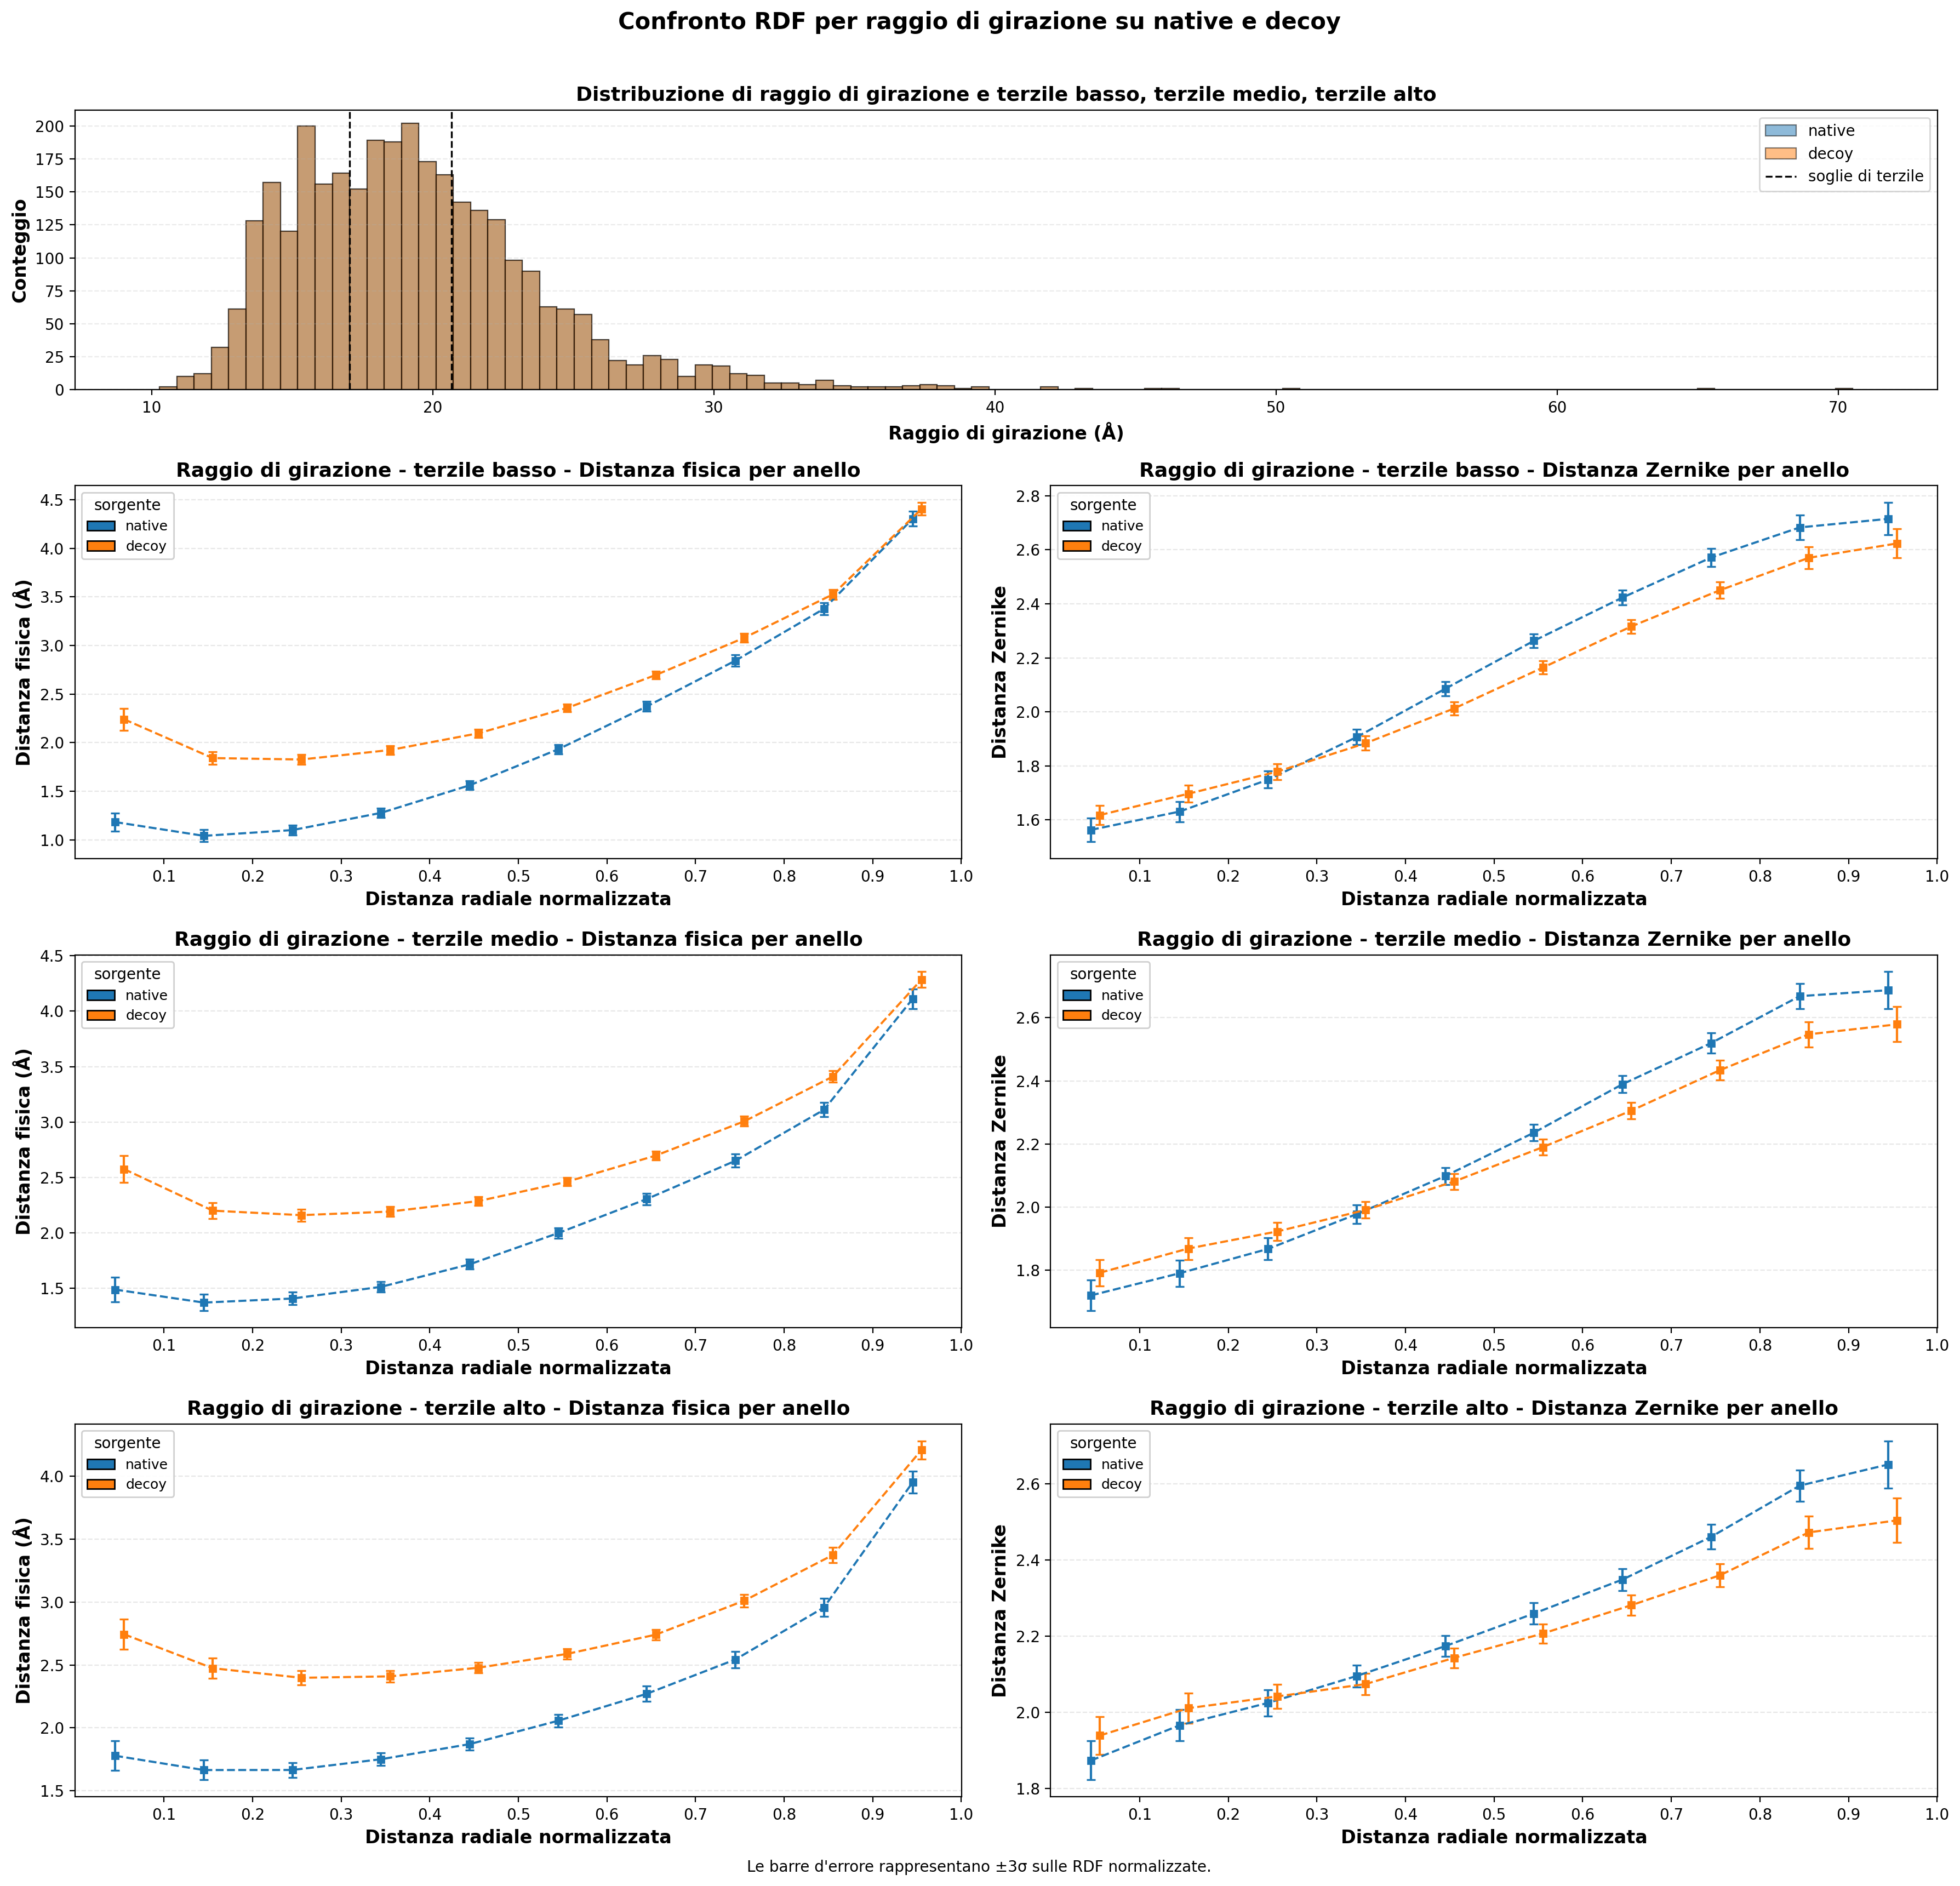

In [3]:
import re
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FILE_LABELS = ['native', 'decoy']
FILE_COLORS = ['#1f77b4', '#ff7f0e']
SUMMARY_ORDER = ['weighted', 'normal']
SUMMARY_STYLES = {
    'weighted': {'marker': 'o', 'linestyle': '-'},
    'normal': {'marker': 's', 'linestyle': '--'},
}
TERTILES = ['low', 'medium', 'large']
TERTILE_LABELS_IT = {'low': 'basso', 'medium': 'medio', 'large': 'alto'}
TERTILE_COLORS = {'low': '#1b9e77', 'medium': '#d95f02', 'large': '#7570b3'}
FEATURE_LABELS_IT = {
    'gyration_radius': 'Raggio di girazione',
    'roughness': 'Roughness',
}
METRIC_LABELS_IT = {
    'physical': 'Distanza fisica (Å)',
    'zernike': 'Distanza Zernike',
}


def _ordered_summary_types(values):
    summary_types = [summary_type for summary_type in SUMMARY_ORDER if summary_type in values]
    for summary_type in values:
        if summary_type not in summary_types:
            summary_types.append(summary_type)
    return summary_types


def _ring_ids_from_columns(columns, prefix):
    pattern = re.compile(rf'^{re.escape(prefix)}(\d+)_(?:mean|uncertainty)$')
    ring_ids = set()
    for column in columns:
        match = pattern.match(column)
        if match is not None:
            ring_ids.add(int(match.group(1)))
    if not ring_ids:
        raise ValueError(f'Non trovo colonne con prefisso {prefix!r}')
    return sorted(ring_ids)


def _mean_and_sample_uncertainty(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return float('nan'), float('nan')
    mean_value = float(np.mean(values))
    if len(values) == 1:
        return mean_value, 0.0
    uncertainty = float(np.std(values, ddof=1) / np.sqrt(len(values)))
    return mean_value, uncertainty


def _propagated_mean_uncertainty(uncertainties):
    uncertainties = np.asarray(uncertainties, dtype=float)
    uncertainties = uncertainties[np.isfinite(uncertainties)]
    if len(uncertainties) == 0:
        return float('nan')
    if len(uncertainties) == 1:
        return float(uncertainties[0])
    return float(np.sqrt(np.sum(uncertainties ** 2)) / len(uncertainties))


def _combined_uncertainty(sample_uncertainty, propagated_uncertainty):
    if not np.isfinite(sample_uncertainty) and not np.isfinite(propagated_uncertainty):
        return float('nan')
    if not np.isfinite(sample_uncertainty):
        return float(propagated_uncertainty)
    if not np.isfinite(propagated_uncertainty):
        return float(sample_uncertainty)
    return float(np.sqrt(sample_uncertainty ** 2 + propagated_uncertainty ** 2))


def _finite_feature_values(df_summary, feature_name):
    if 'complex_name' not in df_summary.columns:
        raise ValueError('La colonna complex_name serve per costruire i quantili')
    if feature_name not in df_summary.columns:
        raise ValueError(f'La colonna {feature_name} è richiesta')

    feature_values = []
    for complex_name, complex_group in df_summary.groupby('complex_name', sort=False):
        values = pd.to_numeric(complex_group[feature_name], errors='coerce').to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue
        feature_values.append((complex_name, float(values[0])))

    if not feature_values:
        return pd.DataFrame(columns=['complex_name', feature_name])

    return pd.DataFrame(feature_values, columns=['complex_name', feature_name])


def _quantile_thresholds(feature_values, probabilities=None):
    if len(feature_values) == 0:
        return float('nan'), float('nan')
    if probabilities is None:
        probabilities = [1 / 3, 1 / 3, 1 / 3]
    cumulative_probabilities = np.cumsum(np.asarray(probabilities, dtype=float))[:-1]
    q1, q2 = np.quantile(feature_values, cumulative_probabilities)
    return float(q1), float(q2)


def _tertile_from_value(value, low_threshold, high_threshold):
    if not np.isfinite(value):
        return None
    if value <= low_threshold:
        return 'low'
    if value <= high_threshold:
        return 'medium'
    return 'large'


def _complex_names_by_tertile(df_summary, feature_name, low_threshold, high_threshold):
    feature_df = _finite_feature_values(df_summary, feature_name)
    tertile_map = {tertile: [] for tertile in TERTILES}
    if feature_df.empty:
        return tertile_map

    for _, row in feature_df.iterrows():
        tertile = _tertile_from_value(row[feature_name], low_threshold, high_threshold)
        if tertile is not None:
            tertile_map[tertile].append(row['complex_name'])
    return tertile_map


def _aggregate_metric_by_summary_type(df_summary, summary_types, ring_ids, metric_prefix, complex_names=None):
    aggregated = {}
    complex_name_filter = set(complex_names) if complex_names is not None else None

    for summary_type in summary_types:
        group = df_summary[df_summary['summary_type'] == summary_type]
        ring_values = {}
        per_ring_values = {rid: [] for rid in ring_ids}
        per_ring_uncertainties = {rid: [] for rid in ring_ids}

        if 'complex_name' not in group.columns:
            raise ValueError('La colonna complex_name serve per aggregare per complesso')

        for complex_name, complex_group in group.groupby('complex_name', sort=False):
            if complex_name_filter is not None and complex_name not in complex_name_filter:
                continue

            complex_means = []
            complex_uncertainties = []

            for rid in ring_ids:
                mean_col = f'{metric_prefix}_ring{rid}_mean'
                unc_col = f'{metric_prefix}_ring{rid}_uncertainty'
                if mean_col not in complex_group.columns:
                    complex_means.append(float('nan'))
                    complex_uncertainties.append(float('nan'))
                    continue

                value = float(complex_group[mean_col].iloc[0])
                uncertainty = float(complex_group[unc_col].iloc[0]) if unc_col in complex_group.columns else float('nan')
                complex_means.append(value)
                complex_uncertainties.append(uncertainty)

            for rid, value, uncertainty in zip(ring_ids, complex_means, complex_uncertainties):
                if np.isfinite(value):
                    per_ring_values[rid].append(value)
                if np.isfinite(uncertainty):
                    per_ring_uncertainties[rid].append(uncertainty)

        for rid in ring_ids:
            finite_means = np.array(per_ring_values[rid], dtype=float)
            finite_uncertainties = np.array(per_ring_uncertainties[rid], dtype=float)
            if len(finite_means) == 0:
                ring_values[rid] = {
                    'mean': float('nan'),
                    'sample_uncertainty': float('nan'),
                    'propagated_uncertainty': float('nan'),
                    'combined_uncertainty': float('nan'),
                    'count': 0,
                }
                continue

            mean_value, sample_uncertainty = _mean_and_sample_uncertainty(finite_means)
            propagated_uncertainty = _propagated_mean_uncertainty(finite_uncertainties)
            combined_uncertainty = _combined_uncertainty(sample_uncertainty, propagated_uncertainty)

            ring_values[rid] = {
                'mean': mean_value,
                'sample_uncertainty': sample_uncertainty,
                'propagated_uncertainty': propagated_uncertainty,
                'combined_uncertainty': combined_uncertainty,
                'count': int(len(finite_means)),
            }

        aggregated[summary_type] = ring_values

    return aggregated


def _feature_values_by_source(df_summaries, feature_name):
    return [
        _finite_feature_values(df_summary, feature_name)[feature_name].to_numpy(dtype=float)
        for df_summary in df_summaries
    ]


def _hist_legend_label(probabilities=None, feature_name=None):
    if feature_name == 'gyration_radius':
        return 'soglie di terzile'
    if probabilities is None:
        return 'soglie di quantile'
    percentages = ', '.join(f'{probability * 100:.1f}%' for probability in probabilities)
    return f'soglie di quantile [{percentages}]'


def _plot_hist_panel(ax, feature_values_by_source, source_labels, thresholds, feature_name, feature_label, probabilities=None):
    if any(len(values) > 0 for values in feature_values_by_source):
        bins = np.histogram_bin_edges(np.concatenate([values for values in feature_values_by_source if len(values) > 0]), bins='auto')
    else:
        bins = 10

    threshold_label = _hist_legend_label(probabilities, feature_name)
    for source_values, source_label, color in zip(feature_values_by_source, source_labels, FILE_COLORS):
        ax.hist(
            source_values,
            bins=bins,
            color=color,
            alpha=0.5 if len(feature_values_by_source) > 1 else 0.75,
            edgecolor='black',
            linewidth=0.8,
            label=source_label,
        )

    for threshold_index, threshold in enumerate(thresholds):
        if np.isfinite(threshold):
            ax.axvline(
                threshold,
                color='black',
                linestyle='--',
                linewidth=1.2,
                label=threshold_label if threshold_index == 0 else None,
            )

    feature_xlabel = f'{feature_label} (Å)'
    ax.set_xlabel(feature_xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel('Conteggio', fontsize=12, fontweight='bold')
    if feature_name == 'gyration_radius':
        title_suffix = 'terzile basso, terzile medio, terzile alto'
    else:
        title_suffix = 'quantile basso, quantile medio, quantile alto'
    ax.set_title(f'Distribuzione di {feature_label.lower()} e {title_suffix}', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.legend(fontsize=10, loc='best')


def _plot_dual_file_normalized_panel(
    ax,
    file_data,
    x_positions,
    summary_types,
    metric_label,
    value_label,
    file_labels,
    point_uncertainty_scale=3.0,
):
    x_base = np.arange(0.1, 0.1 * len(x_positions) + 0.001, 0.1)
    source_offsets = {
        'native': -0.055,
        'decoy': -0.045,
    }

    for file_index, file_label in enumerate(file_labels):
        x_values = x_base + source_offsets.get(file_label, 0.0)
        for summary_type in summary_types:
            ring_values = file_data[file_index][summary_type]
            keys = list(ring_values.keys())
            means = np.array([ring_values[key]['mean'] for key in keys], dtype=float)
            uncertainties = np.array([ring_values[key]['combined_uncertainty'] for key in keys], dtype=float)
            style = SUMMARY_STYLES.get(summary_type, {'marker': 'o', 'linestyle': '-'})
            ax.errorbar(
                x_values,
                means,
                yerr=uncertainties * point_uncertainty_scale,
                fmt='none',
                ecolor=FILE_COLORS[file_index % len(FILE_COLORS)],
                elinewidth=1.5,
                capsize=3,
                capthick=1.2,
                zorder=2,
            )
            ax.plot(
                x_values,
                means,
                color=FILE_COLORS[file_index % len(FILE_COLORS)],
                marker=style['marker'],
                linestyle=style['linestyle'],
                linewidth=1.4,
                markersize=4.5,
                zorder=3,
            )

    ax.set_xlabel('Distanza radiale normalizzata', fontsize=12, fontweight='bold')
    ax.set_ylabel(value_label, fontsize=12, fontweight='bold')
    ax.set_title(metric_label, fontsize=13, fontweight='bold')
    ax.set_xticks(x_base)
    ax.set_xticklabels([f'{value:.1f}' for value in x_base])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    file_handles = [
        Patch(facecolor=FILE_COLORS[file_index % len(FILE_COLORS)], edgecolor='black', label=file_label)
        for file_index, file_label in enumerate(file_labels)
    ]
    legend1 = ax.legend(handles=file_handles, title='sorgente', fontsize=9, loc='upper left')
    ax.add_artist(legend1)


def plot_feature_quantile_comparison(feature_name, feature_label, probabilities=None):
    df_summaries = [native_df.copy(), decoys_df.copy()]
    source_labels = FILE_LABELS

    ring_ids = _ring_ids_from_columns(df_summaries[0].columns, 'physical_ring')
    summary_types = _ordered_summary_types(
        sorted({summary_type for df_summary in df_summaries for summary_type in df_summary['summary_type'].dropna().unique().tolist()})
    )

    feature_values_by_source = _feature_values_by_source(df_summaries, feature_name)
    combined_feature_values = np.concatenate([values for values in feature_values_by_source if len(values) > 0]) if any(len(values) > 0 for values in feature_values_by_source) else np.array([], dtype=float)
    low_threshold, high_threshold = _quantile_thresholds(combined_feature_values, probabilities)
    print(f'  {feature_name}: soglie = {low_threshold:.6g}, {high_threshold:.6g}')

    tertile_data_by_source = []
    for df_summary in df_summaries:
        tertile_complex_names = _complex_names_by_tertile(df_summary, feature_name, low_threshold, high_threshold)
        source_data = {}
        for tertile in TERTILES:
            source_data[tertile] = {
                'physical': _aggregate_metric_by_summary_type(
                    df_summary,
                    summary_types,
                    ring_ids,
                    'physical',
                    complex_names=tertile_complex_names[tertile],
                ),
                'zernike': _aggregate_metric_by_summary_type(
                    df_summary,
                    summary_types,
                    ring_ids,
                    'zernike',
                    complex_names=tertile_complex_names[tertile],
                ),
            }
        tertile_data_by_source.append(source_data)

    fig = plt.figure(figsize=(18, 18))
    gs = fig.add_gridspec(4, 2, height_ratios=[0.9, 1.2, 1.2, 1.2])
    ax_hist = fig.add_subplot(gs[0, :])

    _plot_hist_panel(
        ax_hist,
        feature_values_by_source,
        source_labels,
        (low_threshold, high_threshold),
        feature_name,
        feature_label,
        probabilities,
    )

    x_positions = np.array([(ring_id - 0.5) / 10.0 for ring_id in ring_ids], dtype=float)
    x_tick_positions = np.arange(0.1, 1.01, 0.1)
    x_tick_labels = [f'{value:.1f}' for value in x_tick_positions]

    for row_index, tertile in enumerate(TERTILES, start=1):
        ax_physical = fig.add_subplot(gs[row_index, 0])
        ax_zernike = fig.add_subplot(gs[row_index, 1])

        tertile_prefix = 'terzile' if feature_name == 'gyration_radius' else 'quantile'
        tertile_title = f'{tertile_prefix} {TERTILE_LABELS_IT[tertile]}'

        _plot_dual_file_normalized_panel(
            ax_physical,
            [tertile_data_by_source[file_index][tertile]['physical'] for file_index in range(len(df_summaries))],
            x_positions,
            summary_types,
            f'{feature_label} - {tertile_title} - Distanza fisica per anello',
            METRIC_LABELS_IT['physical'],
            source_labels,
            point_uncertainty_scale=3.0,
        )
        _plot_dual_file_normalized_panel(
            ax_zernike,
            [tertile_data_by_source[file_index][tertile]['zernike'] for file_index in range(len(df_summaries))],
            x_positions,
            summary_types,
            f'{feature_label} - {tertile_title} - Distanza Zernike per anello',
            METRIC_LABELS_IT['zernike'],
            source_labels,
            point_uncertainty_scale=3.0,
        )

        ax_physical.set_xticks(x_tick_positions)
        ax_physical.set_xticklabels(x_tick_labels)
        ax_zernike.set_xticks(x_tick_positions)
        ax_zernike.set_xticklabels(x_tick_labels)

    fig.suptitle(
        f'Confronto RDF per {feature_label.lower()} su native e decoy',
        fontsize=15,
        fontweight='bold',
        y=0.995,
    )
    fig.text(
        0.5,
        0.05,
        'Le barre d\'errore rappresentano ±3σ sulle RDF normalizzate.',
        ha='center',
        va='bottom',
        fontsize=10,
    )
    fig.tight_layout(rect=(0, 0.055, 1, 0.985))
    plt.show()


plot_feature_quantile_comparison('gyration_radius', FEATURE_LABELS_IT['gyration_radius'])

## Roughness
I decoys tendono ad avere roughness più basse, come avevamo visto anche dalla RDF roughness.

Per roughness molto alte la differenza tra RDF native e decoy si appiattisce, anche se a onor del vero i decoys non hanno molta statistica in questa zona

  roughness: soglie = 3.13991, 6.63646


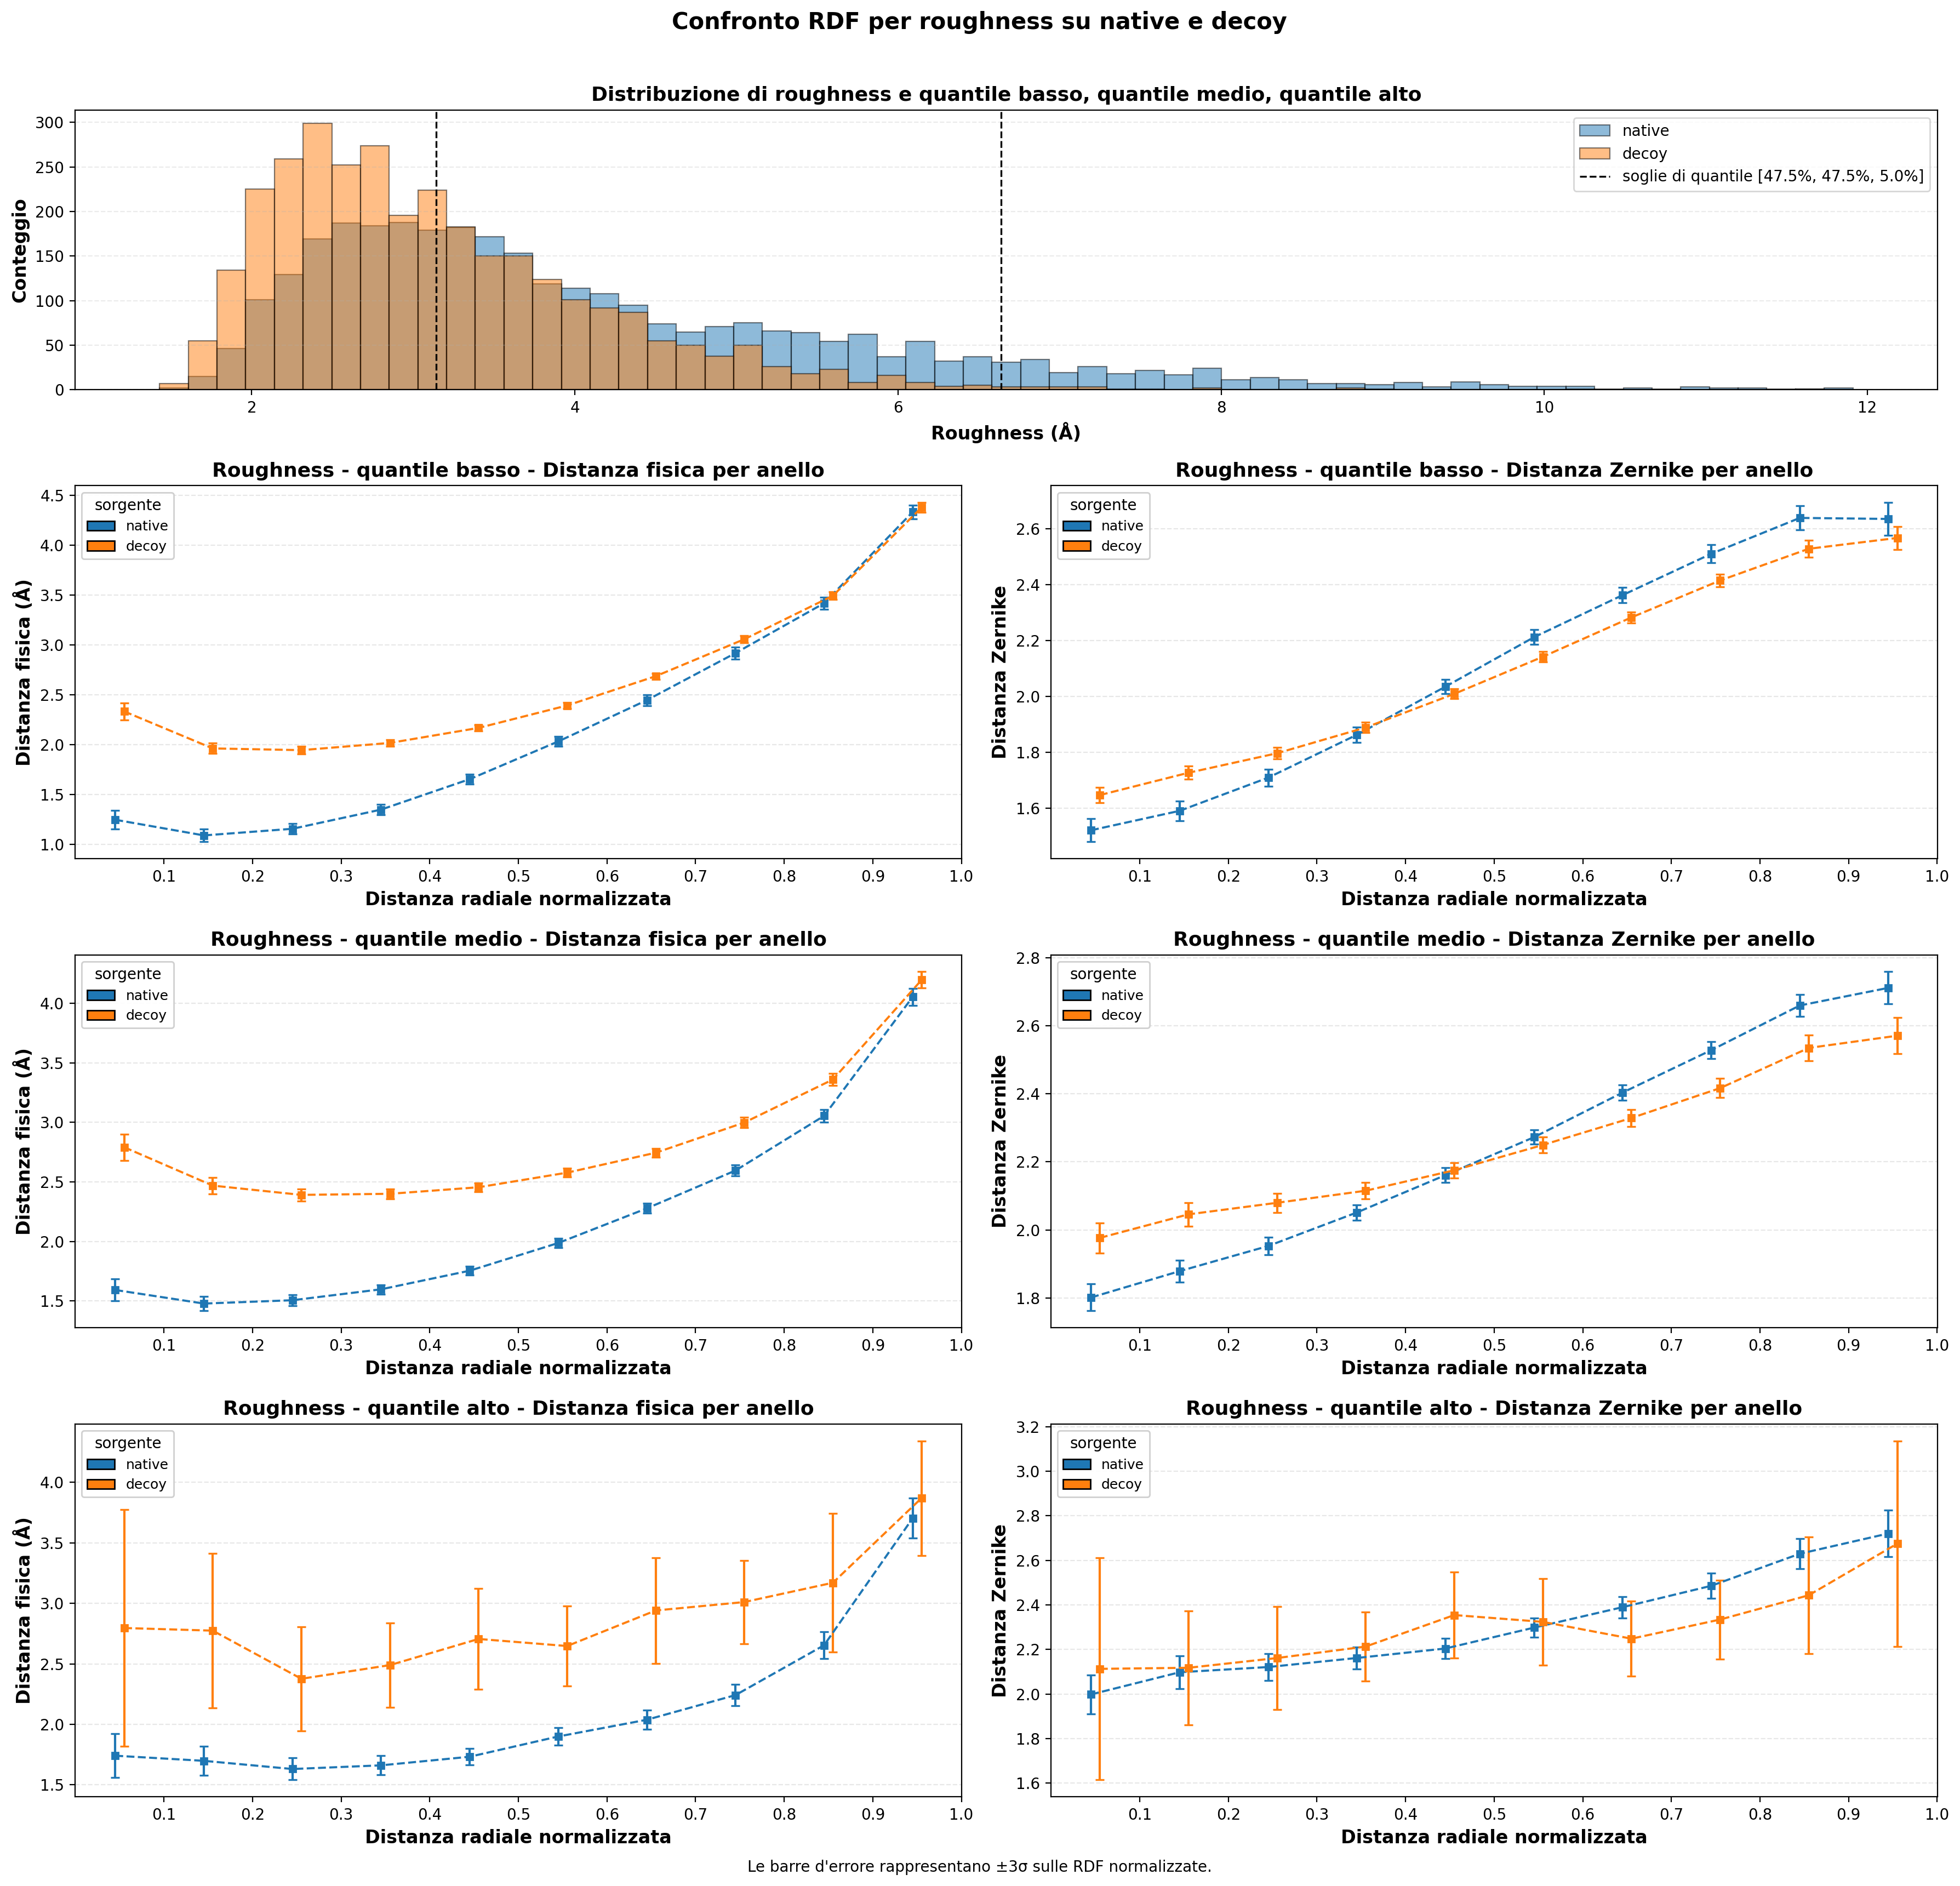

In [4]:
plot_feature_quantile_comparison('roughness', FEATURE_LABELS_IT['roughness'], probabilities=[0.475, 0.475, 0.05])

In realtà se si guarda il rapporto roughness native / roughness decoy per ogni complesso si vede che ci sono anche molti complessi in cui la roughness del decoy è minore di quella native, ma la distribuzione è sbilanciata verso rapporti >1

Il raggio di girazione non sembra avere effetti significativi sulla mediana della roughness. Forse l'effetto principale è che al crescere del raggio di girazione aumenta la frequenza di complessi in cui la roughness del decoy è molto più piccola della roughness native.

In [5]:
def _plot_dual_file_normalized_panel(
    ax,
    file_data,
    x_positions,
    summary_types,
    metric_label,
    value_label,
    file_labels,
    point_uncertainty_scale=3.0,
):
    x_base = np.arange(0.1, 0.1 * len(x_positions) + 0.001, 0.1)
    source_offsets = {
        'native': -0.055,
        'decoy': -0.045,
    }

    for file_index, file_label in enumerate(file_labels):
        x_values = x_base + source_offsets.get(file_label, 0.0)
        for summary_type in summary_types:
            ring_values = file_data[file_index][summary_type]
            keys = list(ring_values.keys())
            means = np.array([ring_values[key]['mean'] for key in keys], dtype=float)
            uncertainties = np.array([ring_values[key]['combined_uncertainty'] for key in keys], dtype=float)
            style = SUMMARY_STYLES.get(summary_type, {'marker': 'o', 'linestyle': '-'})
            ax.errorbar(
                x_values,
                means,
                yerr=uncertainties * point_uncertainty_scale,
                fmt='none',
                ecolor=FILE_COLORS[file_index % len(FILE_COLORS)],
                elinewidth=1.5,
                capsize=3,
                capthick=1.2,
                zorder=2,
            )
            ax.plot(
                x_values,
                means,
                color=FILE_COLORS[file_index % len(FILE_COLORS)],
                marker=style['marker'],
                linestyle=style['linestyle'],
                linewidth=1.4,
                markersize=4.5,
                zorder=3,
            )

    ax.set_xlabel('Distanza radiale normalizzata', fontsize=12, fontweight='bold')
    ax.set_ylabel(value_label, fontsize=12, fontweight='bold')
    ax.set_title(metric_label, fontsize=13, fontweight='bold')
    ax.set_xticks(x_base)
    ax.set_xticklabels([f'{value:.1f}' for value in x_base])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    file_handles = [
        Patch(facecolor=FILE_COLORS[file_index % len(FILE_COLORS)], edgecolor='black', label=file_label)
        for file_index, file_label in enumerate(file_labels)
    ]
    legend1 = ax.legend(handles=file_handles, title='sorgente', fontsize=9, loc='upper left')
    ax.add_artist(legend1)

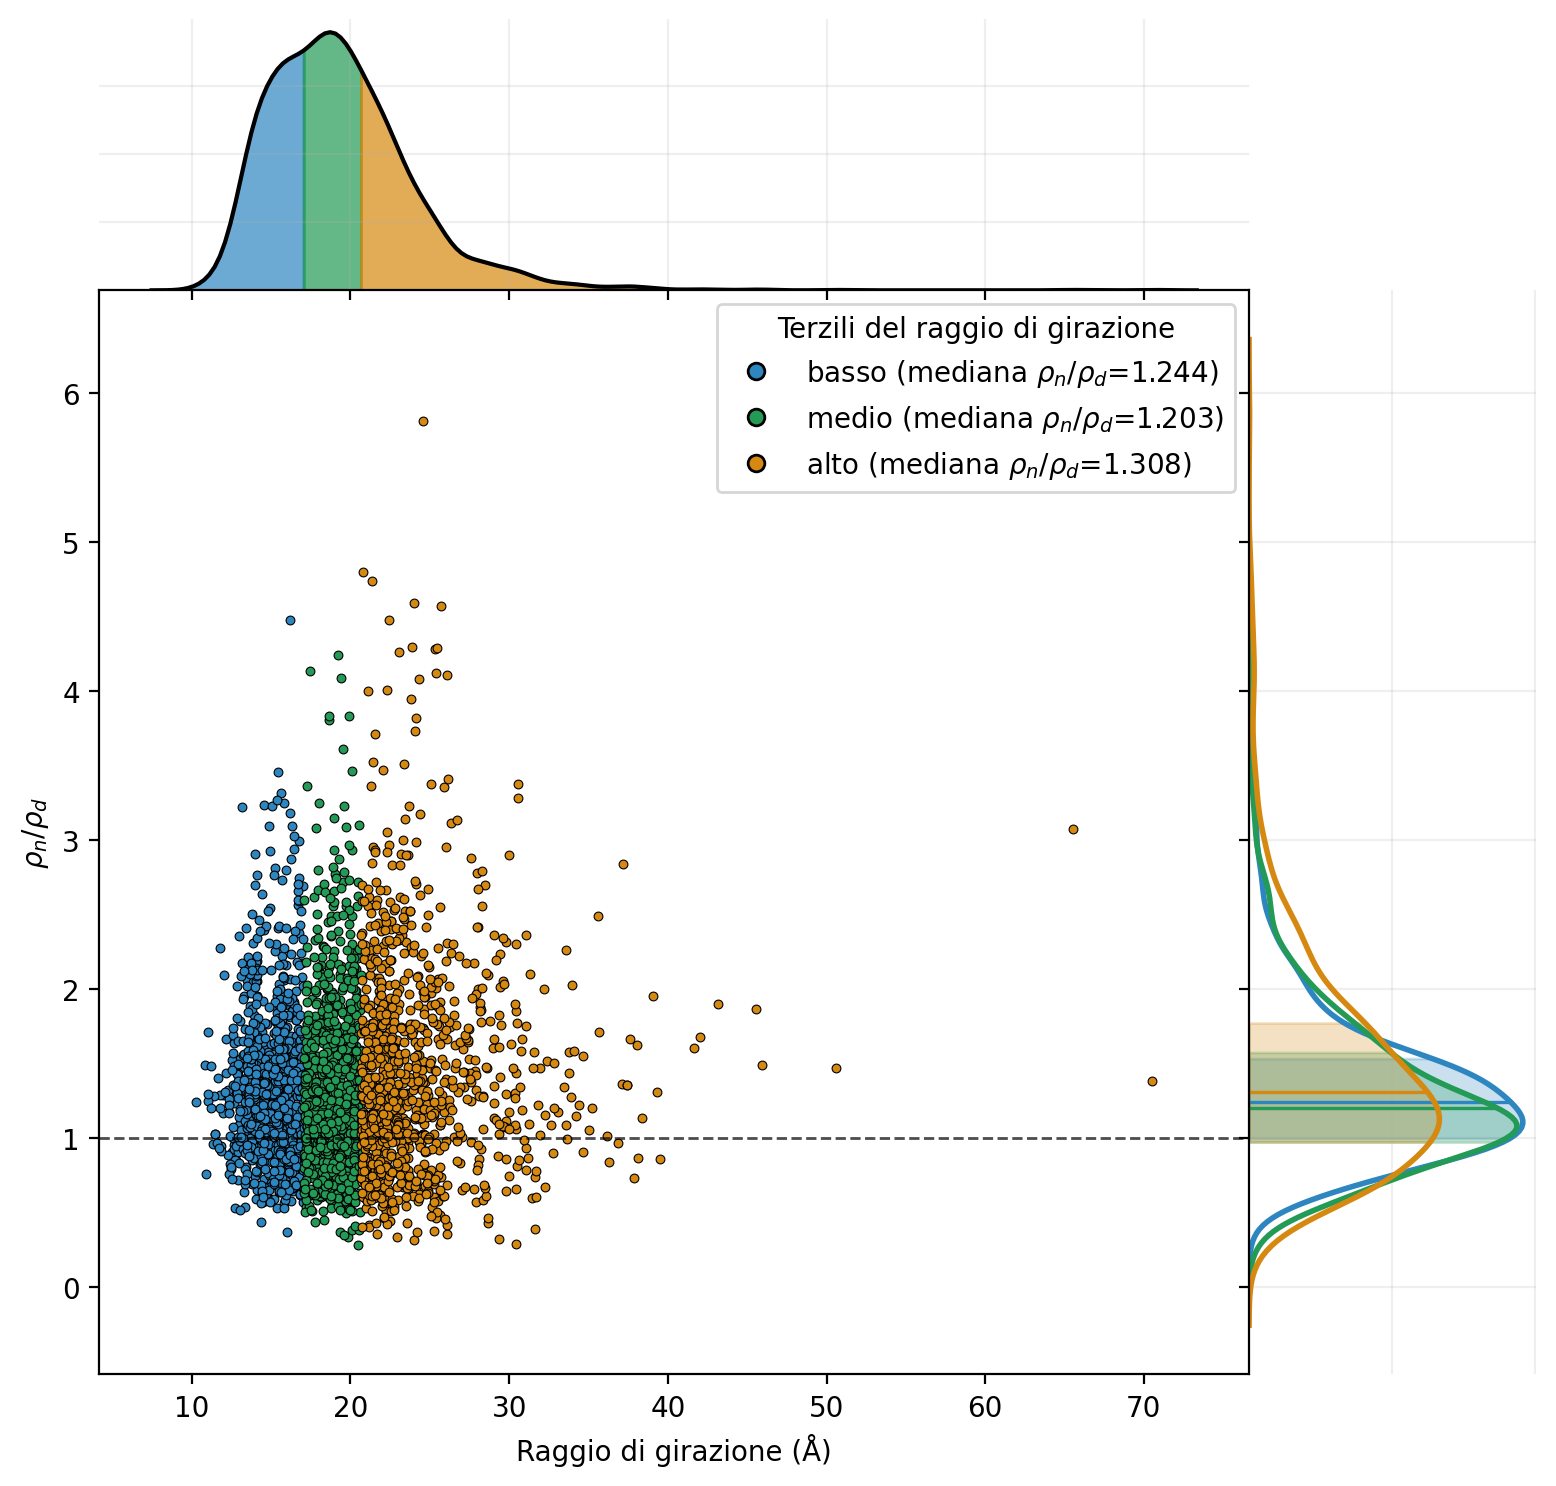

Numero complessi usati nel plot: 3134
Soglie terzili Rg (A): 17.051139311230344 20.66810326373692

Statistiche rho_n/rho_d per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045  1.244422  0.986994  1.554072
medium      1044  1.202665  0.965730  1.595058
large       1045  1.308145  0.974662  1.782626


In [6]:
from matplotlib.lines import Line2D

# Versione della cella 2 con y = rho_n / rho_d al posto di q
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
)

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['rho_ratio'] = plot_df['roughness_native'] / plot_df['roughness_decoy']

# Terzili del raggio di girazione
q1, q2 = plot_df['gyration_radius_A'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['gyration_radius_A'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'large']
)

# Statistiche di rho_ratio per terzile: mediana e IQR
ratio_stats = (
    plot_df.groupby('size_class', observed=False)['rho_ratio']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
)

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
class_labels = {'low': 'basso', 'medium': 'medio', 'large': 'alto'}

g = sns.JointGrid(data=plot_df, x='gyration_radius_A', y='rho_ratio', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale del raggio di girazione (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='gyration_radius_A',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
)

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()
x_order = np.argsort(x_data)
x_data = x_data[x_order]
x_density = x_density[x_order]
xmin, xmax = float(x_data.min()), float(x_data.max())

# Riempie sotto la KDE del raggio di girazione per ciascun terzile
segment_bounds = [xmin, q1, q2, xmax]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    segment_x = x_data[segment_mask]
    segment_y = x_density[segment_mask]
    if segment_x.size == 0:
        segment_x = np.array([left_bound, right_bound])
        segment_y = np.interp(segment_x, x_data, x_density)
    else:
        if segment_x[0] > left_bound:
            segment_x = np.r_[left_bound, segment_x]
            segment_y = np.r_[np.interp(left_bound, x_data, x_density), segment_y]
        if segment_x[-1] < right_bound:
            segment_x = np.r_[segment_x, right_bound]
            segment_y = np.r_[segment_y, np.interp(right_bound, x_data, x_density)]
    g.ax_marg_x.fill_between(
        segment_x,
        0,
        segment_y,
        color=tertile_colors[cls],
        alpha=0.7,
        interpolate=True
    )

# Marginale y: distribuzioni di rho_n / rho_d per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'rho_ratio'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = ratio_stats.loc[cls, 'median']
    q25 = ratio_stats.loc[cls, 'q25']
    q75 = ratio_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = float(np.interp(med, y_data, y_density)) if len(y_data) > 1 else float(y_density[0])
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Scatter centrale
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='gyration_radius_A',
        y='rho_ratio',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in ratio_stats.index or pd.isna(ratio_stats.loc[cls, 'median']):
        continue
    med = ratio_stats.loc[cls, 'median']
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=f"{class_labels[cls]} (mediana $\\rho_n/\\rho_d$={med:.3f})"
        )
    )

g.ax_joint.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Raggio di girazione (Å)')
g.ax_joint.set_ylabel(r'$\rho_n/\rho_d$')
g.ax_joint.legend(handles=legend_handles, title='Terzili del raggio di girazione')

g.ax_marg_x.set_ylabel('Densità')
g.ax_marg_y.set_xlabel('Densità')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili Rg (A):', float(q1), float(q2))
print('\nStatistiche rho_n/rho_d per terzile (mediana e IQR):')
print(ratio_stats[['n', 'median', 'q25', 'q75']])

Se invece plottiamo il rapporto in funzione della roughness native vediamo un andamento lineare: più la roughness native è alta e più il decoy tenderà ad avere una roughness in proporzione più bassa. In altre parole la roughness decoy non è proporzionale alla roughness native, aumenta più lentamente

Inoltre è interessante che nel terzile più basso della roughness native abbiamo invece in media che il decoy mantiene la stessa roughness.

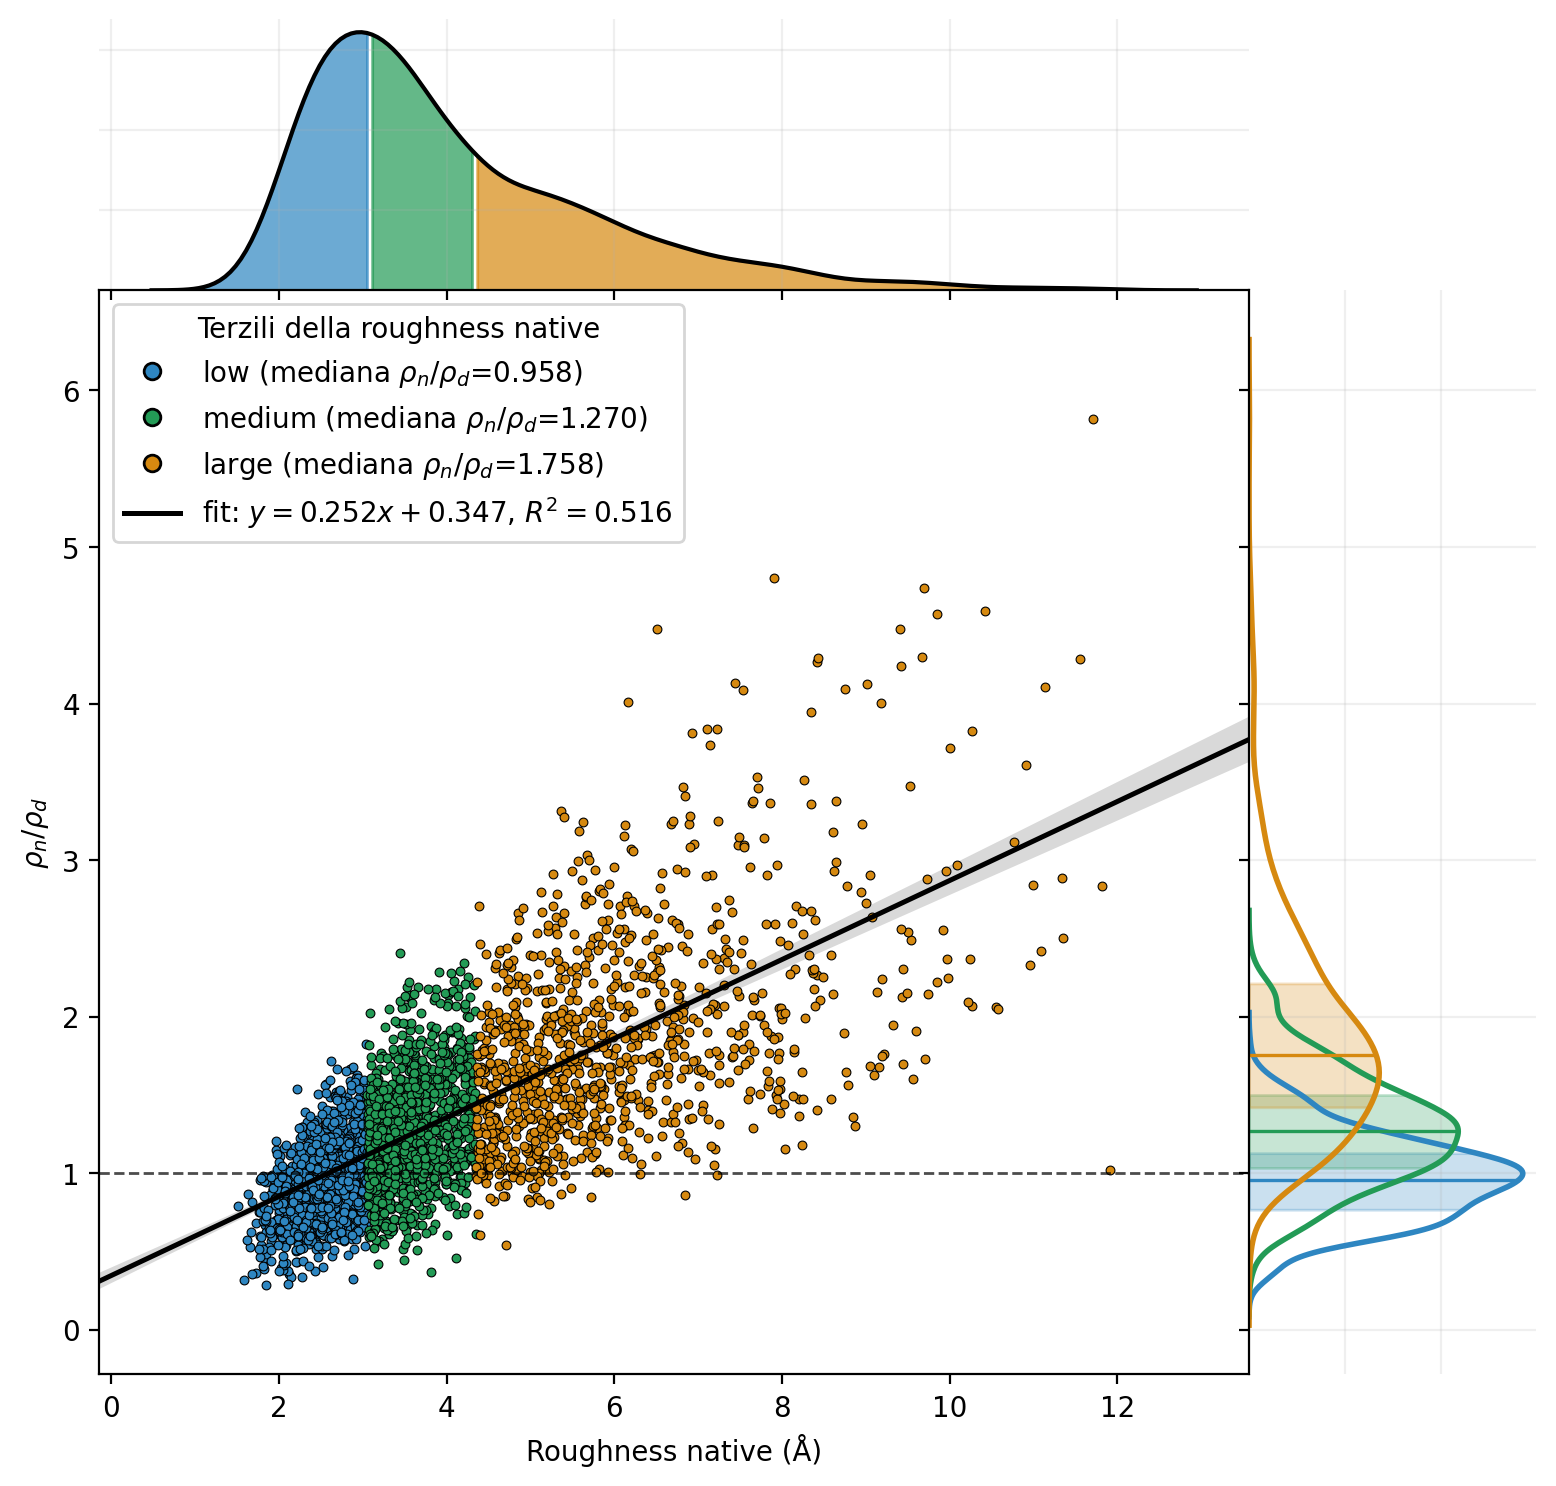

Numero complessi usati nel plot: 3134
Soglie terzili roughness native: 3.0547927303499818 4.351447539876785

Conteggio complessi rispetto alla retta del fit per terzile:
low: sopra=493, sotto=552, uguali=0
medium: sopra=538, sotto=506, uguali=0
large: sopra=455, sotto=590, uguali=0

Statistiche rho_n/rho_d per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045  0.957769  0.760435  1.136803
medium      1044  1.270316  1.031385  1.508002
large       1045  1.757888  1.398443  2.216226


In [7]:
from matplotlib.lines import Line2D

# Versione della cella rho_n / rho_d con asse x = roughness native
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
)

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['rho_ratio'] = plot_df['roughness_native'] / plot_df['roughness_decoy']

# Terzili della roughness native
x_low, x_high = plot_df['roughness_native'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['roughness_native'],
    bins=[-np.inf, x_low, x_high, np.inf],
    labels=['low', 'medium', 'large']
)

# Statistiche di rho_ratio per terzile: mediana e IQR
ratio_stats = (
    plot_df.groupby('size_class', observed=False)['rho_ratio']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
)

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

g = sns.JointGrid(data=plot_df, x='roughness_native', y='rho_ratio', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale della roughness native (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='roughness_native',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
)

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()

# Riempie sotto la KDE della roughness native per ciascun terzile
xmin, xmax = x_data.min(), x_data.max()
segment_bounds = [xmin, x_low, x_high, xmax]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    if not np.any(segment_mask):
        continue
    g.ax_marg_x.fill_between(
        x_data[segment_mask],
        0,
        x_density[segment_mask],
        color=tertile_colors[cls],
        alpha=0.7
    )

# Marginale y: distribuzioni di rho_n / rho_d per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'rho_ratio'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = ratio_stats.loc[cls, 'median']
    q25 = ratio_stats.loc[cls, 'q25']
    q75 = ratio_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = float(np.interp(med, y_data, y_density)) if len(y_data) > 1 else float(y_density[0])
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Regressione lineare centrale su tutti i punti
sns.regplot(
    data=plot_df,
    x='roughness_native',
    y='rho_ratio',
    ax=g.ax_joint,
    scatter=False,
    line_kws={'color': 'black', 'linewidth': 1.8},
    truncate=False
)

slope, intercept = np.polyfit(plot_df['roughness_native'], plot_df['rho_ratio'], 1)
r_value = np.corrcoef(plot_df['roughness_native'], plot_df['rho_ratio'])[0, 1]
r_squared = r_value ** 2

# Conteggio dei punti sopra/sotto la retta del fit per ciascun terzile
fit_counts = {}
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls].copy()
    if cls_data.empty:
        continue
    y_fit = slope * cls_data['roughness_native'] + intercept
    above = int((cls_data['rho_ratio'] > y_fit).sum())
    below = int((cls_data['rho_ratio'] < y_fit).sum())
    equal = int((cls_data['rho_ratio'] == y_fit).sum())
    fit_counts[cls] = {'above': above, 'below': below, 'equal': equal}

# Punti colorati per terzile, come prima
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='roughness_native',
        y='rho_ratio',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in ratio_stats.index or pd.isna(ratio_stats.loc[cls, 'median']):
        continue
    med = ratio_stats.loc[cls, 'median']
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=fr"{cls} (mediana $\rho_n/\rho_d$={med:.3f})"
        )
    )

legend_handles.append(
    Line2D(
        [0], [0],
        color='black',
        linewidth=1.8,
        label=fr"fit: $y={slope:.3f}x+{intercept:.3f}$, $R^2={r_squared:.3f}$"
    )
)

g.ax_joint.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Roughness native (Å)')
g.ax_joint.set_ylabel(r'$\rho_n/\rho_d$')
g.ax_joint.legend(handles=legend_handles, title='Terzili della roughness native')

g.ax_marg_x.set_ylabel('Densità')
g.ax_marg_y.set_xlabel('Densità')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili roughness native:', float(x_low), float(x_high))
print('\nConteggio complessi rispetto alla retta del fit per terzile:')
for cls in ['low', 'medium', 'large']:
    if cls not in fit_counts:
        continue
    counts = fit_counts[cls]
    print(f"{cls}: sopra={counts['above']}, sotto={counts['below']}, uguali={counts['equal']}")
print('\nStatistiche rho_n/rho_d per terzile (mediana e IQR):')
print(ratio_stats[['n', 'median', 'q25', 'q75']])

Poiché nel grafico precedente la roughness native $\rho_N$ compare sia sull’asse $x$ sia al numeratore del rapporto $\rho_N/\rho_D$, è necessario verificare che l’andamento osservato non sia una conseguenza artificiale della scelta delle variabili.

Per questo motivo è stato costruito un **modello nullo tramite permutazione**. In particolare, i valori di roughness dei decoys $\rho_D$ sono stati permutati casualmente $10000$ volte, rompendo quindi la corrispondenza paired tra ciascun complesso native e il relativo decoy. Per ogni permutazione è stato ripetuto il fit lineare:

$$
\frac{\rho_N}{\rho_D}=\alpha+\beta \rho_N
$$

ottenendo così le distribuzioni nulle dei coefficienti $\alpha$ e $\beta$.

I valori dei coefficienti ottenuti dal fit reale risultano esterni alle distribuzioni generate dal modello nullo. Questo indica che la relazione osservata non è spiegabile soltanto dalla presenza di $\rho_N$ su entrambi gli assi, ma riflette una reale dipendenza tra la roughness del native e quella del corrispondente decoy.

Un aspetto particolarmente interessante è che il modello nullo produce in media valori di $\beta$ maggiori rispetto al fit reale. Questo significa che, quando i decoys vengono associati casualmente ai native, il rapporto $\rho_N/\rho_D$ cresce più rapidamente con $\rho_N$. In altre parole, nel caso random i native ad alta roughness vengono spesso confrontati con decoys non correlati e mediamente più lisci, producendo artificialmente una differenza native-decoy più marcata.

Nel dataset reale, invece, la pendenza più bassa suggerisce che i decoys non sono geometricamente indipendenti dai rispettivi native: essi conservano parzialmente le caratteristiche strutturali del complesso di partenza. Tuttavia, poiché la pendenza reale rimane positiva, questa conservazione è solo parziale: al crescere della roughness native, i decoys tendono comunque a non riprodurre completamente i valori più elevati di roughness osservati nelle interfacce native.

In sintesi, il risultato suggerisce che i decoys mantengono parte della geometria globale del complesso, ma mostrano una compressione della roughness, perdendo soprattutto la coda ad alta roughness tipica delle strutture native.

In [8]:
from matplotlib.lines import Line2D

# Test di permutazione per il fit della cella 7: rho_n / rho_d vs rho_n
# All'interno di ciascun terzile permuto a caso le roughness dei decoy
# e rifaccio il fit lineare 1000 volte, senza plottare i singoli fit.

rng = np.random.default_rng(42)
n_permutations = 10000

# Ricavo il dataset di lavoro della cella 7 in modo autosufficiente
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness']]
    .mean()
)
rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')

perm_df = pd.DataFrame(index=rough_pivot.index)
perm_df['rho_n'] = rough_pivot.get('native')
perm_df['rho_d'] = rough_pivot.get('decoy')
perm_df = perm_df.dropna(subset=['rho_n', 'rho_d']).copy()
perm_df = perm_df[(perm_df['rho_n'] > 0) & (perm_df['rho_d'] > 0)].copy()

q_low, q_high = perm_df['rho_n'].quantile([1/3, 2/3])
perm_df['size_class'] = pd.cut(
    perm_df['rho_n'],
    bins=[-np.inf, q_low, q_high, np.inf],
    labels=['low', 'medium', 'large']
)

# Fit vero della cella 7, usato come riferimento: rho_n / rho_d = alpha + beta * rho_n
true_beta, true_alpha = np.polyfit(perm_df['rho_n'], perm_df['rho_n'] / perm_df['rho_d'], 1)

perm_alphas = []
perm_betas = []

for _ in range(n_permutations):
    permuted = perm_df.copy()

    # Permuto i decoy solo dentro ciascun terzile della riga native
    for cls in ['low', 'medium', 'large']:
        cls_mask = permuted['size_class'] == cls
        idx = permuted.index[cls_mask]
        if len(idx) == 0:
            continue
        permuted.loc[idx, 'rho_d'] = rng.permutation(permuted.loc[idx, 'rho_d'].to_numpy())

    x = permuted['rho_n'].to_numpy()
    y = (permuted['rho_n'] / permuted['rho_d']).to_numpy()
    beta_perm, alpha_perm = np.polyfit(x, y, 1)
    perm_alphas.append(alpha_perm)
    perm_betas.append(beta_perm)

perm_alphas = np.asarray(perm_alphas)
perm_betas = np.asarray(perm_betas)

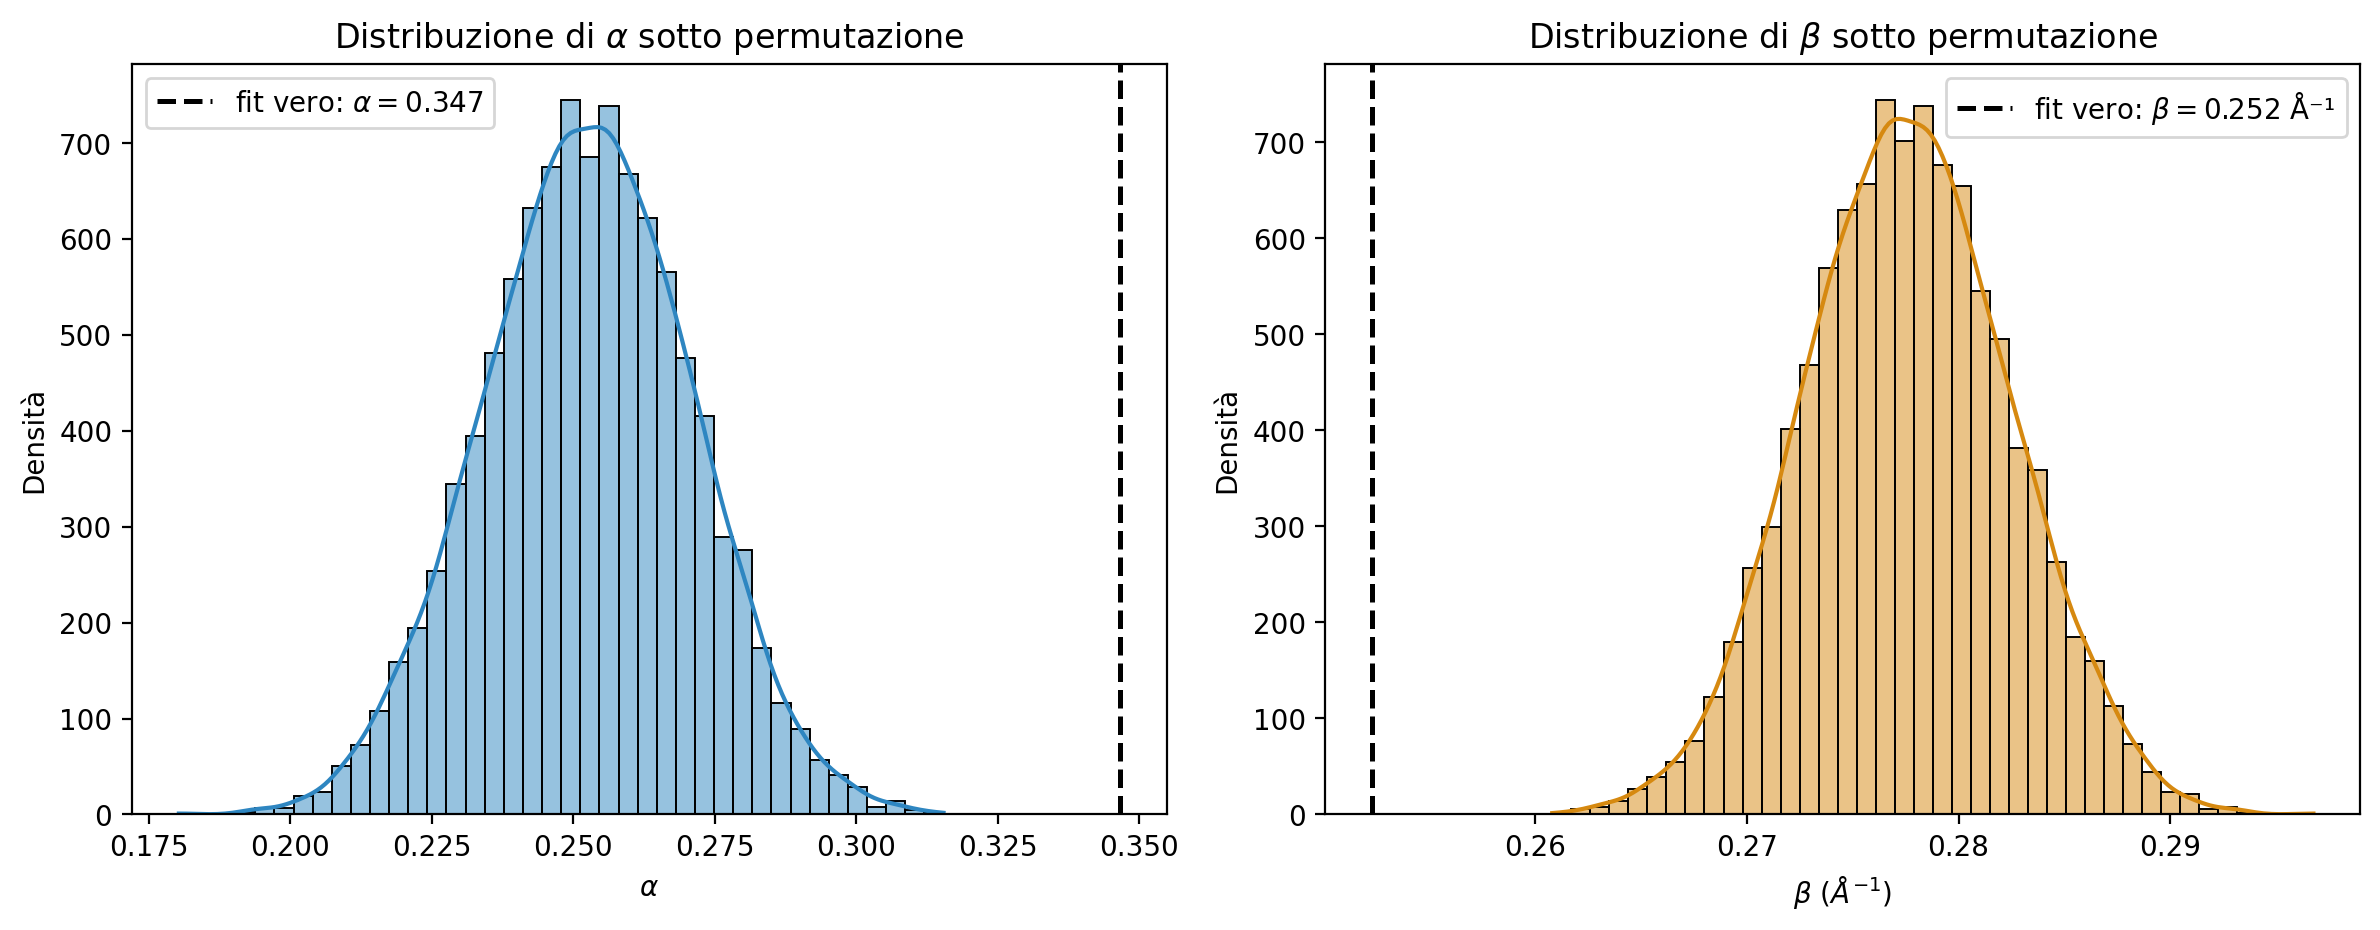

Numero complessi usati nel test: 3134
alpha vero = 0.346571
beta vero = 0.252327
alpha permutati: media=0.252494, std=0.018390
beta permutati: media=0.277596, std=0.004866


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.histplot(perm_alphas, bins=40, kde=True, color='#2e86c1', ax=axes[0])
axes[0].axvline(true_alpha, color='black', linestyle='--', linewidth=1.8, label=fr'fit vero: $\alpha={true_alpha:.3f}$')
axes[0].set_title(r'Distribuzione di $\alpha$ sotto permutazione')
axes[0].set_xlabel(r'$\alpha$')
axes[0].set_ylabel('Densità')
axes[0].legend(loc='best')

sns.histplot(perm_betas, bins=40, kde=True, color='#d68910', ax=axes[1])
axes[1].axvline(true_beta, color='black', linestyle='--', linewidth=1.8, label=fr'fit vero: $\beta={true_beta:.3f}$ Å⁻¹')
axes[1].set_title(r'Distribuzione di $\beta$ sotto permutazione')
axes[1].set_xlabel(r'$\beta$ $(Å^{-1}$)')
axes[1].set_ylabel('Densità')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

print('Numero complessi usati nel test:', len(perm_df))
print(f'alpha vero = {true_alpha:.6f}')
print(f'beta vero = {true_beta:.6f}')
print(f'alpha permutati: media={perm_alphas.mean():.6f}, std={perm_alphas.std(ddof=1):.6f}')
print(f'beta permutati: media={perm_betas.mean():.6f}, std={perm_betas.std(ddof=1):.6f}')

## Raggio del binding site
Nel confronto paired tra il raggio del binding site nel native $r_N$ e nel decoy $r_D$, il fit lineare mostra una relazione del tipo:

$$
r_D = a + b r_N
$$

con intercetta positiva $a>0$ e pendenza $b<1$.

La bisettrice:

$$
r_D = r_N
$$

rappresenta la condizione in cui native e decoy hanno lo stesso raggio del binding site.

Il fatto che la pendenza sia minore di 1 indica che il raggio del binding site nei decoys cresce all’aumentare del raggio native, ma in modo meno che proporzionale. Tuttavia, l’aspetto più importante è che l’intercetta non è nulla. Se il comportamento fosse semplicemente una riduzione proporzionale del raggio nei decoys, ci si aspetterebbe una relazione circa del tipo:

$$
r_D = b r_N
$$

con la retta passante per l’origine. Invece, la presenza di un’intercetta positiva suggerisce che la relazione non sia una semplice sottostima costante, ma una vera **compressione verso valori intermedi**.

In altre parole, il fit non indica che i decoys abbiano sempre un raggio più piccolo dei native. Piuttosto, suggerisce che i decoys tendano a ridurre il range dinamico dei raggi del binding site:

- per valori piccoli di $r_N$, il termine di intercetta fa sì che $r_D$ possa risultare comparabile o anche maggiore di $r_N$;
- per valori intermedi di $r_N$, native e decoy risultano mediamente simili;
- per valori grandi di $r_N$, la pendenza $b<1$ fa sì che $r_D$ cresca meno rapidamente di $r_N$, portando quindi a una sottostima del raggio nei decoys.

In sintesi, il raggio del binding site appare più conservato rispetto alla roughness, ma mostra comunque una tendenza alla compressione nei decoys: le pose decoy preservano in parte la scala spaziale dell’interfaccia, ma riproducono meno accuratamente i binding site native molto piccoli o molto estesi.

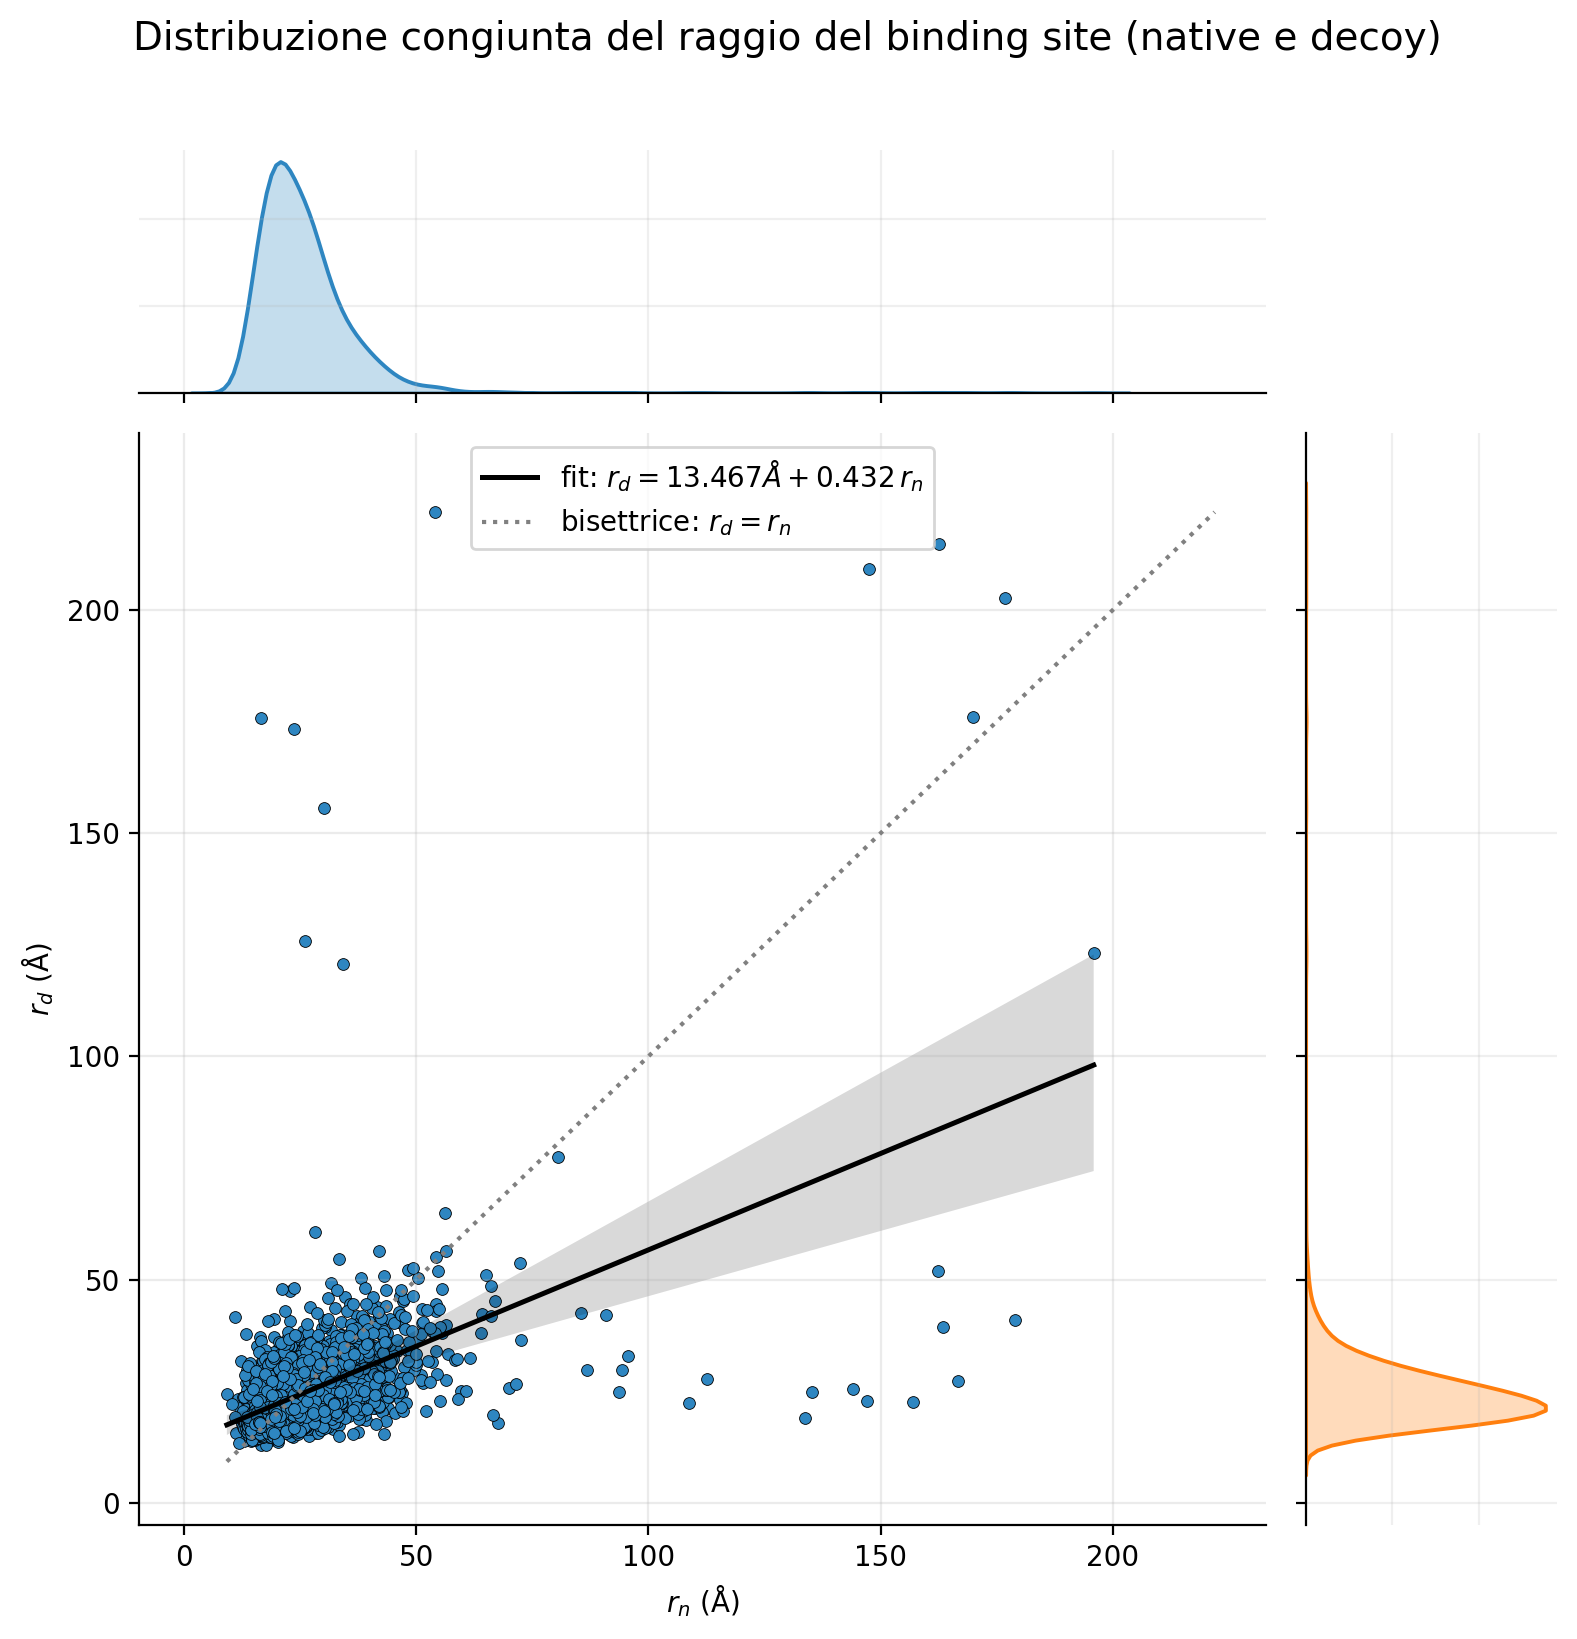

Numero complessi usati nel plot: 3134
alpha = 13.466853
beta = 0.431844


In [10]:
from matplotlib.lines import Line2D

# Joint plot: scatter + fit line, con distribuzioni marginali di raggio native e decoy
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['radius']]
    .mean()
)

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='radius')

plot_df_lr = pd.DataFrame(index=rough_pivot.index)
plot_df_lr['rho_n'] = rough_pivot.get('native')
plot_df_lr['rho_d'] = rough_pivot.get('decoy')
plot_df_lr = plot_df_lr.dropna(subset=['rho_n', 'rho_d']).copy()
plot_df_lr = plot_df_lr[(plot_df_lr['rho_n'] > 0) & (plot_df_lr['rho_d'] > 0)].copy()

beta, alpha = np.polyfit(plot_df_lr['rho_n'], plot_df_lr['rho_d'], 1)

# JointGrid per controllare anche i marginal plot
joint_grid = sns.JointGrid(data=plot_df_lr, x='rho_n', y='rho_d', height=8, ratio=4, space=0)

sns.scatterplot(
    data=plot_df_lr,
    x='rho_n',
    y='rho_d',
    color='#2e86c1',
    s=18,
    edgecolor='black',
    linewidth=0.3,
    ax=joint_grid.ax_joint,
)

sns.regplot(
    data=plot_df_lr,
    x='rho_n',
    y='rho_d',
    scatter=False,
    ax=joint_grid.ax_joint,
    color='black',
    line_kws={'linewidth': 1.8},
)

line_min = min(plot_df_lr['rho_n'].min(), plot_df_lr['rho_d'].min())
line_max = max(plot_df_lr['rho_n'].max(), plot_df_lr['rho_d'].max())
joint_grid.ax_joint.plot([line_min, line_max], [line_min, line_max], color='gray', linestyle=':', linewidth=1.5)

# Marginali: distribuzione del raggio native sopra e del raggio decoy a destra
sns.kdeplot(
    data=plot_df_lr,
    x='rho_n',
    ax=joint_grid.ax_marg_x,
    color='#2e86c1',
    fill=True,
    alpha=0.28,
    linewidth=1.4,
)
joint_grid.ax_marg_x.set_ylabel('densità')
joint_grid.ax_marg_x.grid(alpha=0.2)

sns.kdeplot(
    data=plot_df_lr,
    y='rho_d',
    ax=joint_grid.ax_marg_y,
    color='#ff7f0e',
    fill=True,
    alpha=0.28,
    linewidth=1.4,
)
joint_grid.ax_marg_y.set_xlabel('densità')
joint_grid.ax_marg_y.grid(alpha=0.2)

fit_handle = Line2D(
    [0], [0],
    color='black',
    linewidth=1.8,
    label=fr'fit: $r_d={alpha:.3f}Å+{beta:.3f}\,r_n$'
)
bisector_handle = Line2D(
    [0], [0],
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label=r'bisettrice: $r_d=r_n$'
)

joint_grid.ax_joint.legend(handles=[fit_handle, bisector_handle], loc='best')
joint_grid.ax_joint.set_xlabel(r'$r_n$ (Å)')
joint_grid.ax_joint.set_ylabel(r'$r_d$ (Å)')
joint_grid.ax_joint.grid(alpha=0.25)
joint_grid.fig.suptitle('Distribuzione congiunta del raggio del binding site (native e decoy)', fontsize=14, y=1.02)
joint_grid.fig.tight_layout()
plt.show()

print('Numero complessi usati nel plot:', len(plot_df_lr))
print(f'alpha = {alpha:.6f}')
print(f'beta = {beta:.6f}')

# PCA
### Interpretazione della PCA sui profili radiali Zernike

La PCA è stata applicata ai profili radiali della distanza Zernike, considerando insieme sia i complessi native sia i decoys. Ogni complesso è quindi rappresentato da un vettore di 10 valori:

$$
g_Z(r_1), g_Z(r_2), \dots, g_Z(r_{10})
$$

dove ciascuna componente corrisponde al valore medio della distanza Zernike in uno dei 10 anelli concentrici del binding site.

L’obiettivo della PCA è individuare le principali direzioni di variabilità dei profili radiali, cioè capire quali combinazioni di anelli spiegano maggiormente le differenze tra i complessi.

---

### Prima componente principale: PCA1

La prima componente principale presenta coefficienti positivi per tutti gli anelli, ma è dominata soprattutto dagli anelli più esterni:

$$
\text{ring 10}: 0.860
$$

$$
\text{ring 9}: 0.447
$$

mentre gli anelli centrali hanno pesi molto più piccoli.

Questo indica che la PCA1 descrive principalmente la variabilità della distanza Zernike nella regione periferica del binding site. In particolare, valori elevati di PCA1 corrispondono a complessi in cui la distanza Zernike è più alta soprattutto negli anelli esterni, cioè nella parte più periferica dell’interfaccia.

Dal punto di vista geometrico, questa componente può essere interpretata come una misura della variabilità della complementarità di forma nella zona esterna del binding site. Poiché una distanza Zernike maggiore indica minore similarità/complementarità tra le patch confrontate, valori alti di PCA1 indicano profili con maggiore dissimilarità Zernike soprattutto alla periferia.

In sintesi:

$$
\text{PCA1} \approx \text{contributo periferico della Zernike RDF}
$$

oppure, più precisamente:

$$
\text{PCA1} \approx \text{variazione degli anelli esterni, soprattutto ring 9-10}
$$

---

### Seconda componente principale: PCA2

La seconda componente principale ha coefficienti positivi negli anelli centrali e intermedi, ma tende a diminuire procedendo verso l’esterno, fino a diventare negativa negli ultimi anelli:

$$
\text{ring 1}: 0.647
$$

$$
\text{ring 2}: 0.520
$$

$$
\text{ring 3}: 0.378
$$

mentre:

$$
\text{ring 9}: -0.023
$$

$$
\text{ring 10}: -0.156
$$

Questo significa che la PCA2 non misura semplicemente un aumento globale della distanza Zernike, ma descrive piuttosto un contrasto tra la regione centrale e la regione periferica del binding site.

Valori alti di PCA2 corrispondono a profili in cui la distanza Zernike è relativamente più alta negli anelli centrali rispetto agli anelli esterni. Al contrario, valori bassi o negativi di PCA2 indicano profili in cui il contributo periferico diventa più rilevante rispetto al core.

Quindi la PCA2 può essere interpretata come una componente di forma radiale, legata al bilanciamento tra core e periferia:

$$
\text{PCA2} \approx \text{contrasto centro-periferia}
$$

In altre parole, mentre PCA1 è dominata soprattutto dagli anelli esterni, PCA2 descrive se la distanza Zernike è concentrata maggiormente nel centro del binding site oppure spostata verso la periferia.

---

### Interpretazione complessiva

La PCA suggerisce che la principale fonte di variabilità nei profili radiali Zernike non riguarda uniformemente tutti gli anelli, ma è fortemente influenzata dagli anelli periferici, in particolare ring 9 e ring 10.

Questo è importante perché indica che gran parte della variabilità della Zernike RDF deriva dalla parte esterna del binding site. Di conseguenza, eventuali differenze tra complessi possono essere molto sensibili alla definizione del raggio massimo, alla presenza di punti periferici e al modo in cui vengono campionati gli anelli esterni.

La seconda componente, invece, contiene un’informazione più strutturale sulla forma del profilo radiale, perché distingue profili più centrali da profili più periferici.

---

### Separazione tra native e decoys

Poiché la PCA è stata applicata congiuntamente a complessi native e decoys, ci si potrebbe aspettare che, se la Zernike RDF fosse fortemente discriminante, i due gruppi occupassero regioni diverse nello spazio delle prime componenti principali.

Tuttavia, la distribuzione dei punti native e decoy risulta ampiamente sovrapponibile. Questo indica che le principali direzioni di variabilità dei profili Zernike non coincidono con una separazione netta tra pose native e decoys.

In altre parole, la distanza Zernike media per anello, considerata come profilo radiale globale, non sembra essere sufficiente da sola per distinguere chiaramente native e decoys.

Questo non significa necessariamente che l’informazione Zernike sia assente, ma suggerisce che il segnale discriminante sia più sottile. A maggior ragione un tentativo di usare il machine learning è quindi più che giustificato.

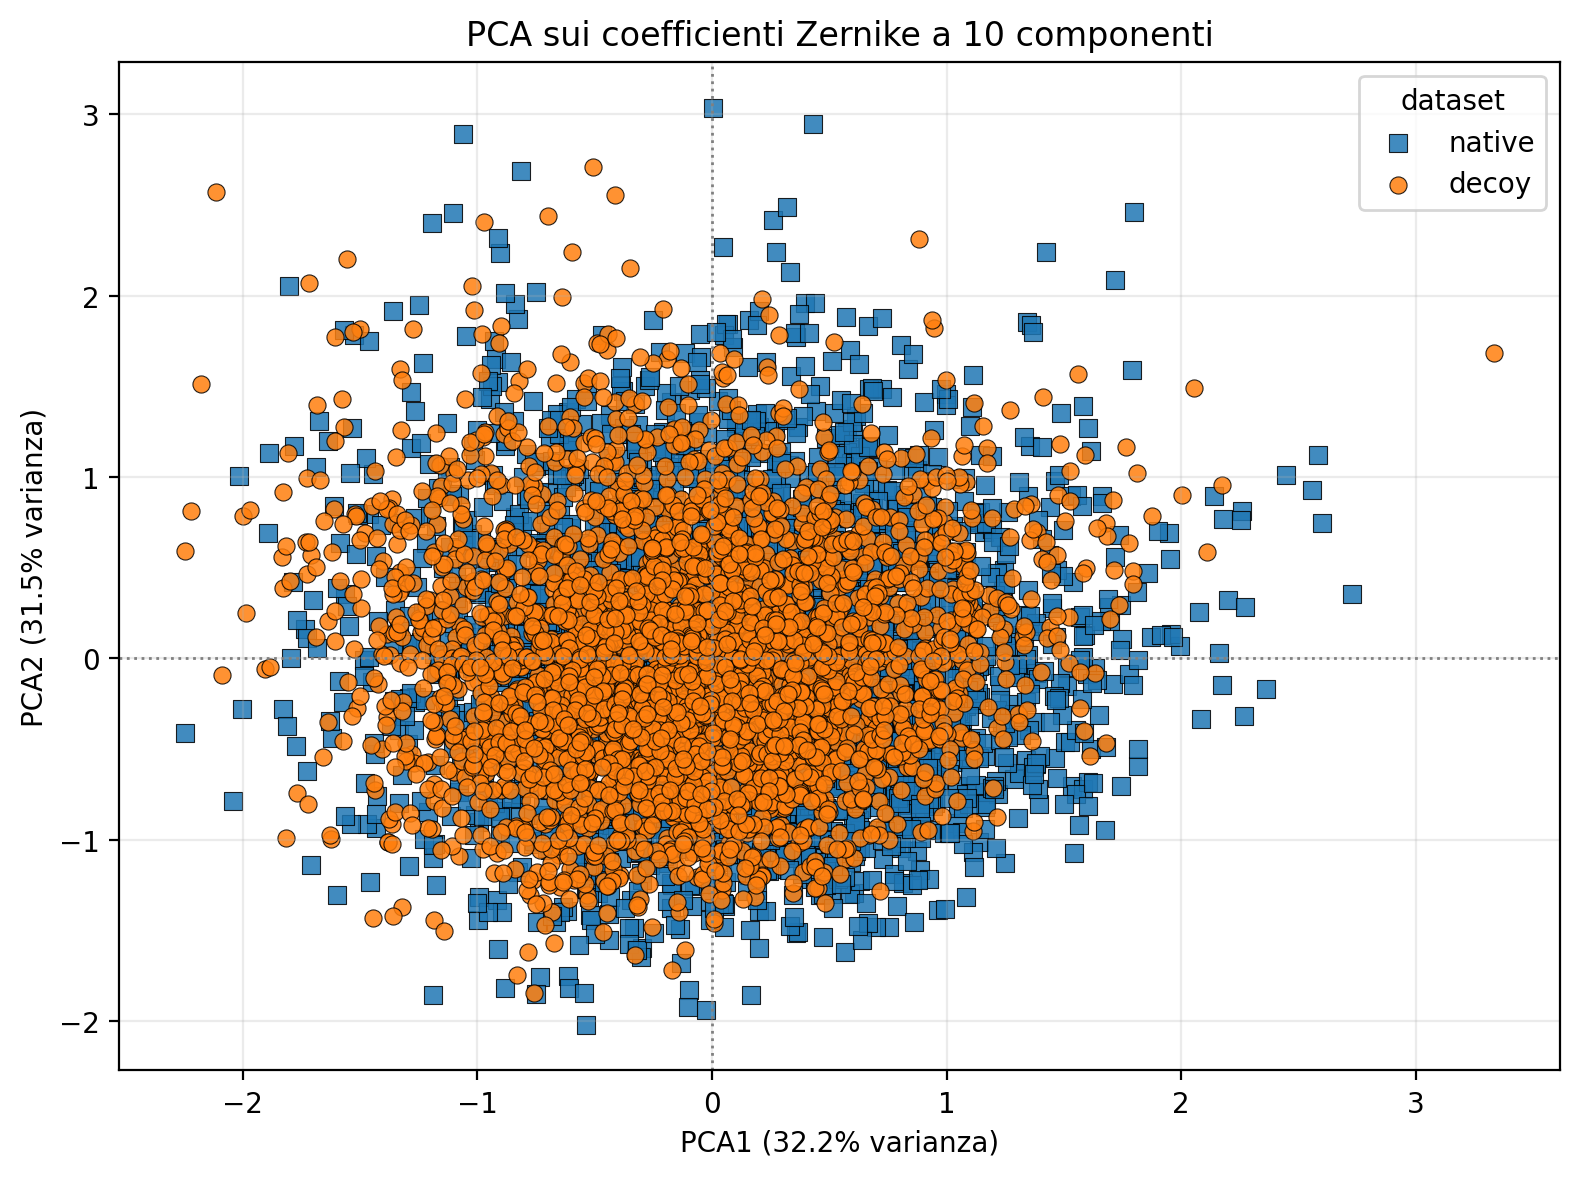

Numero complessi usati nella PCA: 6068
Varianza spiegata: [0.32244401 0.31455723 0.12493671]
Trasformazioni dai coefficienti Zernike a PCA1, PCA2 e PCA3:


,PCA1,PCA2,PCA3
zernike_ring1_mean,-0.306575,0.549400,-0.181055
zernike_ring2_mean,-0.272068,0.475619,-0.080170
zernike_ring3_mean,-0.192531,0.369210,0.042531
zernike_ring4_mean,-0.119937,0.266744,0.171902
zernike_ring5_mean,-0.058391,0.178507,0.289593
zernike_ring6_mean,0.002696,0.113049,0.395814
zernike_ring7_mean,0.072963,0.076045,0.477763
zernike_ring8_mean,0.204024,0.086516,0.494542
zernike_ring9_mean,0.455068,0.221496,0.251341
zernike_ring10_mean,0.723246,0.396868,-0.391022


In [12]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

zernike_cols = [f'zernike_ring{n}_mean' for n in range(1, 11)]
missing_zernike_cols = [col for col in zernike_cols if col not in tot_df.columns]
if missing_zernike_cols:
    raise ValueError(f'Mancano queste colonne Zernike in tot_df: {missing_zernike_cols}')

pca_input = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[zernike_cols]
    .mean(numeric_only=True)
    .dropna(subset=zernike_cols)
    .copy()
)

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(pca_input[zernike_cols].to_numpy(dtype=float))

pca_df = pca_input[['complex_name', 'dataset_label']].copy()
pca_df['PCA1'] = pca_scores[:, 0]
pca_df['PCA2'] = pca_scores[:, 1]
# Garantisce 3 componenti per evitare IndexError su PCA3
if pca_scores.shape[1] < 3:
    pca = PCA(n_components=3)
    pca_scores = pca.fit_transform(pca_input[zernike_cols].to_numpy(dtype=float))
    pca_df['PCA1'] = pca_scores[:, 0]
    pca_df['PCA2'] = pca_scores[:, 1]

pca_df['PCA3'] = pca_scores[:, 2]

palette = {'native': '#1f77b4', 'decoy': '#ff7f0e'}
markers = {'native': 's', 'decoy': 'o'}

fig, ax = plt.subplots(figsize=(8, 6))
for dataset_label in ['native', 'decoy']:
    subset = pca_df[pca_df['dataset_label'] == dataset_label]
    if subset.empty:
        continue
    sns.scatterplot(
        data=subset,
        x='PCA1',
        y='PCA2',
        color=palette[dataset_label],
        marker=markers[dataset_label],
        s=38,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.85,
        ax=ax,
        label=dataset_label,
    )

ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel(f"PCA1 ({pca.explained_variance_ratio_[0] * 100:.1f}% varianza)")
ax.set_ylabel(f"PCA2 ({pca.explained_variance_ratio_[1] * 100:.1f}% varianza)")
ax.set_title('PCA sui coefficienti Zernike a 10 componenti')
ax.grid(alpha=0.25)
ax.legend(title='dataset', loc='best')
plt.tight_layout()
plt.show()

components_df = pd.DataFrame(
    pca.components_.T,
    index=zernike_cols,
    columns=['PCA1', 'PCA2', 'PCA3'],
)

print('Numero complessi usati nella PCA:', len(pca_df))
print('Varianza spiegata:', pca.explained_variance_ratio_)
print('Trasformazioni dai coefficienti Zernike a PCA1, PCA2 e PCA3:')
display(components_df)
